# Supplementary Material S1: Reproducible Analysis Notebook

**Manuscript:** Interpretable Gradient Boosting Framework with a Five-Step
Learnability Validation Protocol for Meningitis Clinical Risk Classification

**Authors:** Fathimah Al-Ma'shumah, Yasi Dani, Yani Triyani, Dani Suandi
*Bina Nusantara University; Bandung Islamic University*

---

### Scope

This notebook reproduces every quantitative result in the manuscript and
regenerates Figures 2 to 8 and Tables 1 to 3. Figure 1 in the manuscript is a
workflow diagram and is not produced here.

| Manuscript item | Output file |
|---|---|
| Fig. 2 | `fig_correlation.png` |
| Fig. 3 | `fig_performance_comparison.png` |
| Fig. 4 | `fig1_calibration.png` |
| Fig. 5 | `fig2_dca_outcome.png` |
| Fig. 6 | `fig4_shap_global_comparison.png` |
| Fig. 7 | `fig5_shap_waterfall.png` |
| Fig. 8 | `fig_risk_score.png` |
| Table 1 | classification performance |
| Table 2 | Brier score decomposition |
| Table 3 | five-step protocol verdict |

Two further plots are produced, `fig_eda_distributions.png` and
`fig3_shap_beeswarm.png`. Both were used during analysis but were left out of
the manuscript because they restate what Figures 2 and 6 already show.

### Data acquisition

The next cell resolves the dataset in three tiers, in order:

1. **Local file**: `meningitis.csv` in the working directory.
2. **Automatic download**: public Kaggle dataset
   `chantest/meningitis-classification`, via `kagglehub` or the Kaggle API.
3. **Embedded copy**: a gzip and base64 copy of the dataset carried inside
   this notebook, so it runs with no network access and no Kaggle credentials.

Integrity is verified by SHA-256 against the copy used for the manuscript, so
any tier yields byte-identical data and therefore identical results.

### Environment

Python 3.11 or later with `pandas`, `numpy`, `scikit-learn`, `lightgbm`,
`catboost`, `xgboost`, `shap`, `imbalanced-learn`, `matplotlib`, `seaborn`.

```
pip install pandas numpy scikit-learn lightgbm catboost xgboost shap imbalanced-learn matplotlib seaborn kagglehub
```

All random seeds are fixed at `RANDOM_STATE = 42`.


## Analysis outline

1. Setup and data loading
2. Exploratory analysis and the Step 1 correlation check
3. Preprocessing, stratified split, and SMOTE on the training fold
4. Model training: Logistic Regression, Random Forest, LightGBM, CatBoost, XGBoost
5. Classification performance (Table 1, Fig. 3)
6. Calibration and Brier score decomposition (Table 2, Fig. 4)
7. Decision curve analysis (Fig. 5)
8. Integer risk score derivation (Fig. 8)
9. SHAP attribution analysis (Fig. 6, Fig. 7)


## 1. Setup & Installation

In [1]:
# Install required packages (run once)
import subprocess, sys
pkgs = ['lightgbm', 'catboost', 'xgboost', 'shap', 'imbalanced-learn']
for p in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', p, '-q', '--break-system-packages'],
                   capture_output=True)

In [2]:
import numpy as np
import sklearn
from packaging import version
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, matthews_corrcoef, brier_score_loss,
    classification_report, confusion_matrix, roc_curve
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from imblearn.over_sampling import SMOTE

import lightgbm as lgb
import catboost as cb
import xgboost as xgb
import shap

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
plt.rcParams.update({
    'figure.dpi': 150, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3
})
PALETTE = ['#2E5F8A', '#E8593C', '#1D9E75', '#BA7517', '#7F77DD']
print('All packages loaded successfully.')

All packages loaded successfully.


In [3]:
# Google Drive mount, only when running inside Google Colab.
# Skipped automatically in any other environment (local, JupyterLab, Binder).
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted.")
except ModuleNotFoundError:
    print("Not running in Google Colab - skipping Drive mount.")


Not running in Google Colab - skipping Drive mount.


## 2. Data Loading & Exploratory Analysis

In [4]:
# In this repository the dataset ships as data/meningitis.csv, so the
# embedded fallback copy used in the journal supplement is not needed.
EMBEDDED_CSV_B64 = ""
print("Using data/meningitis.csv from the repository.")


In [5]:
# =====================================================================
# DATA ACQUISITION — local file -> Kaggle download -> embedded fallback
# =====================================================================
import os, io, gzip, base64, hashlib, pandas as pd

DATA_PATH   = "meningitis.csv"
KAGGLE_SLUG = "chantest/meningitis-classification"
EXPECT_SHA  = "ac885b8bcbcaae6d45597fde42b8439f7aa33e1580a0395e2d8133501e75eee0"

def _sha256(b): return hashlib.sha256(b).hexdigest()

def _from_local():
    if os.path.exists(DATA_PATH):
        return open(DATA_PATH, "rb").read(), "local file"
    return None, None

def _from_kaggle():
    # Tier 2a: kagglehub (no credentials needed for public datasets)
    try:
        import kagglehub
        d = kagglehub.dataset_download(KAGGLE_SLUG)
        for root, _, files in os.walk(d):
            for f in files:
                if f.lower().endswith(".csv"):
                    return open(os.path.join(root, f), "rb").read(), "kagglehub"
    except Exception as e:
        print(f"  kagglehub unavailable ({type(e).__name__})")
    # Tier 2b: official Kaggle API (requires ~/.kaggle/kaggle.json)
    try:
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi(); api.authenticate()
        api.dataset_download_files(KAGGLE_SLUG, path=".", unzip=True)
        for f in os.listdir("."):
            if f.lower().endswith(".csv"):
                return open(f, "rb").read(), "kaggle API"
    except Exception as e:
        print(f"  Kaggle API unavailable ({type(e).__name__})")
    return None, None

def _from_embedded():
    return gzip.decompress(base64.b64decode(EMBEDDED_CSV_B64)), "embedded copy"

raw, source = _from_local()
if raw is None:
    print("Local file not found - attempting download...")
    raw, source = _from_kaggle()
if raw is None:
    print("Download unavailable - using the copy embedded in this notebook.")
    raw, source = _from_embedded()

got = _sha256(raw)
print(f"\nSource        : {source}")
print(f"SHA-256       : {got}")
print(f"Integrity     : {'MATCH - identical to the manuscript copy' if got == EXPECT_SHA else 'MISMATCH - results may differ'}")

if not os.path.exists(DATA_PATH):
    open(DATA_PATH, "wb").write(raw)

df = pd.read_csv(io.BytesIO(raw))
print(f"\nShape         : {df.shape}")
print(f"Missing values: {int(df.isna().sum().sum())}")
df.head()



Source        : local file
SHA-256       : ac885b8bcbcaae6d45597fde42b8439f7aa33e1580a0395e2d8133501e75eee0
Integrity     : MATCH - identical to the manuscript copy

Shape         : (1200, 14)
Missing values: 0


,Patient_ID,Age,Gender,WBC_Count,Protein_Level,Glucose_Level,Pathogen_Present,Diagnosis,Outcome,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level,Risk_Level
0,1,66,Female,14450,179,19,Yes,Bacterial,Recovered,3,13912,119405,45,High Risk
1,2,94,Male,13470,122,104,No,Bacterial,Recovered,16,6845,213495,44,Moderate Risk
2,3,23,Male,8921,20,66,No,Viral,Recovered,18,4049,217301,5,Low Risk
3,4,53,Female,16200,145,16,Yes,Bacterial,Recovered,1,17731,119570,44,High Risk
4,5,47,Female,4781,43,58,No,Viral,Recovered,14,5086,259521,0,Low Risk


In [6]:
# Basic statistics
print('=== Missing values ===')
print(df.isnull().sum())
print('\n=== Target distributions ===')
for col in ['Diagnosis', 'Outcome', 'Risk_Level']:
    print(f'\n{col}:')
    print(df[col].value_counts(normalize=True).round(3))

=== Missing values ===
Patient_ID          0
Age                 0
Gender              0
WBC_Count           0
Protein_Level       0
Glucose_Level       0
Pathogen_Present    0
Diagnosis           0
Outcome             0
Hemoglobin          0
WBC_Blood_Count     0
Platelets           0
CRP_Level           0
Risk_Level          0
dtype: int64

=== Target distributions ===

Diagnosis:
Diagnosis
Bacterial    0.496
Viral        0.448
Unknown      0.056
Name: proportion, dtype: float64

Outcome:
Outcome
Recovered    0.897
Deceased     0.103
Name: proportion, dtype: float64

Risk_Level:
Risk_Level
High Risk        0.494
Low Risk         0.450
Moderate Risk    0.056
Name: proportion, dtype: float64


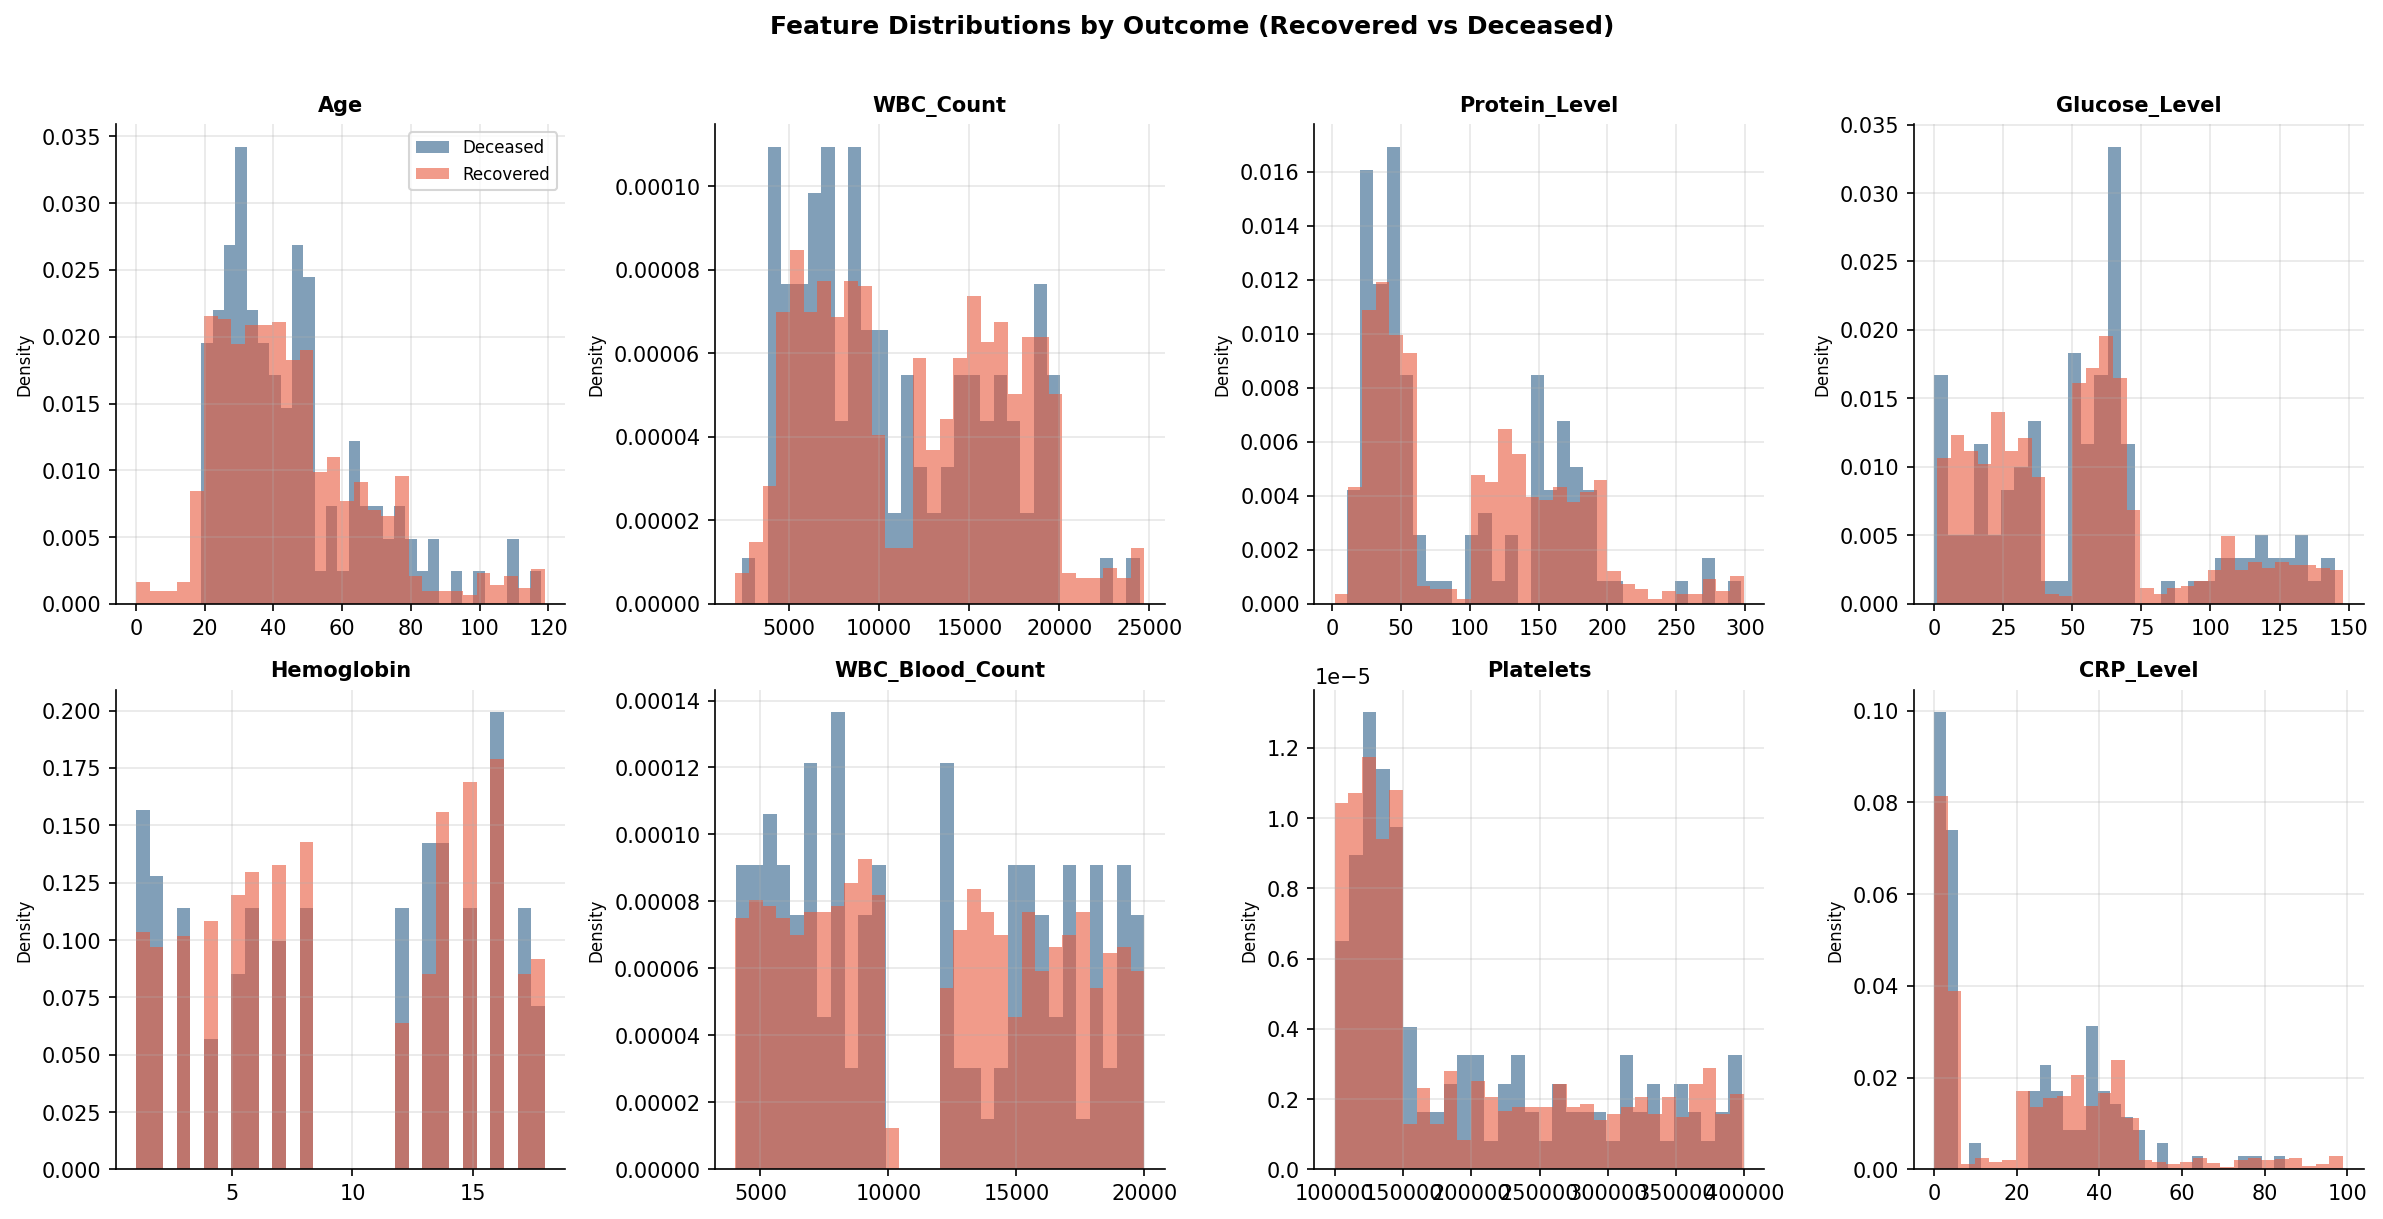

Figure saved: fig_eda_distributions.png


In [7]:
# EDA, distribution plots
continuous_feats = ['Age', 'WBC_Count', 'Protein_Level', 'Glucose_Level',
                    'Hemoglobin', 'WBC_Blood_Count', 'Platelets', 'CRP_Level']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(continuous_feats):
    ax = axes[i]
    for j, (outcome, grp) in enumerate(df.groupby('Outcome')):
        ax.hist(grp[feat], bins=30, alpha=0.6, color=PALETTE[j],
                label=outcome, density=True)
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.set_ylabel('Density', fontsize=8)
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle('Feature Distributions by Outcome (Recovered vs Deceased)',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig_eda_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: fig_eda_distributions.png')

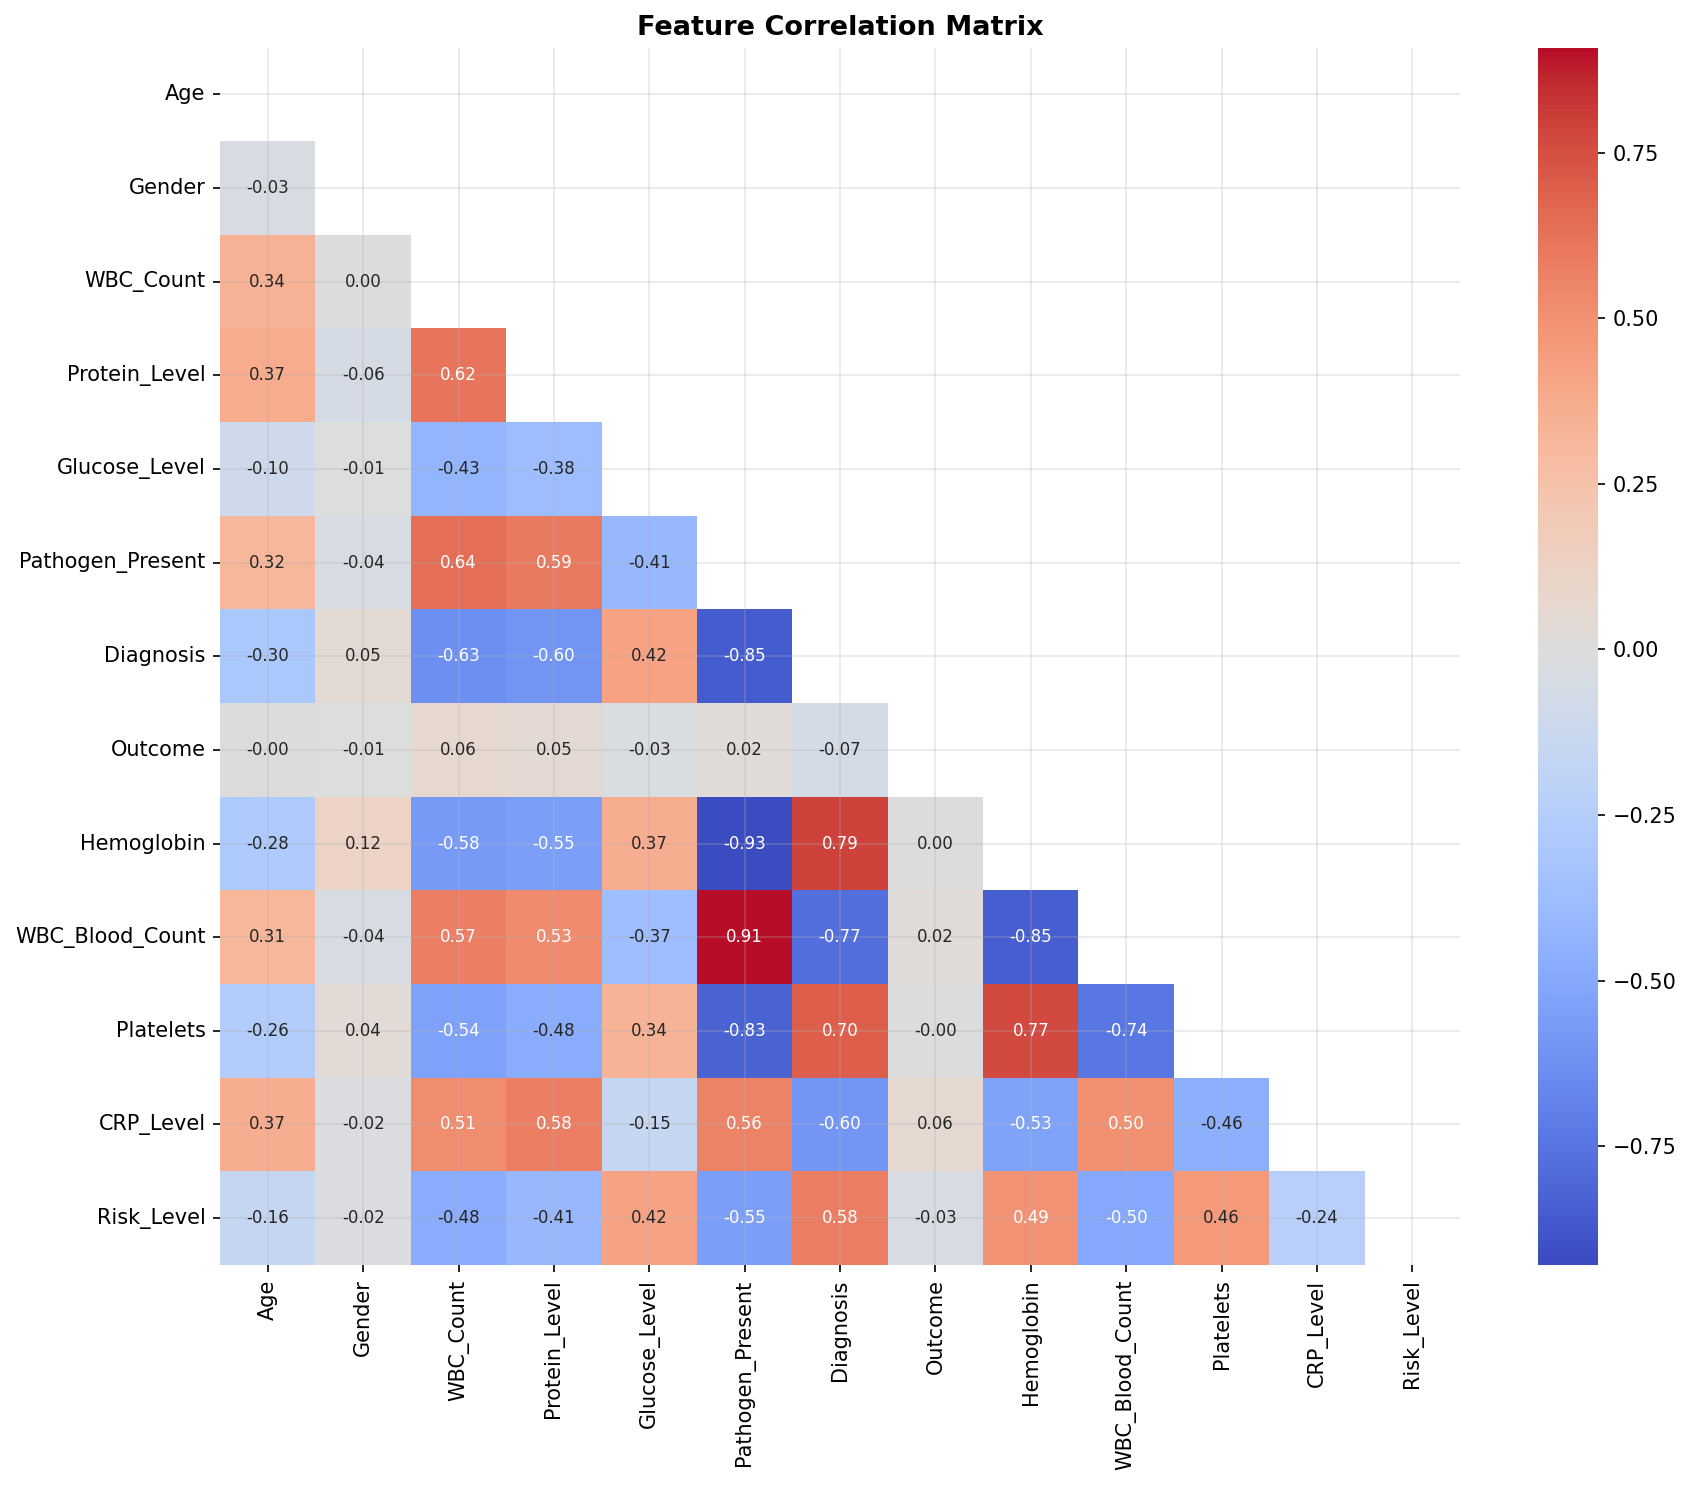

In [8]:
# Correlation heatmap
df_enc = df.copy()
for col in ['Gender', 'Pathogen_Present', 'Diagnosis', 'Outcome', 'Risk_Level']:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

fig, ax = plt.subplots(figsize=(12, 10))
corr = df_enc.drop('Patient_ID', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Preprocessing & SMOTE

In [9]:
# -------------------------------------------------------------------
# Encode categoricals
# -------------------------------------------------------------------
df_model = df.copy()

# Binary encodings
df_model['Gender'] = (df_model['Gender'] == 'Male').astype(int)
df_model['Pathogen_Present'] = (df_model['Pathogen_Present'] == 'Yes').astype(int)

# Target encodings
le_diag = LabelEncoder()
le_outcome = LabelEncoder()
le_risk = LabelEncoder()
df_model['Diagnosis_enc'] = le_diag.fit_transform(df_model['Diagnosis'])
df_model['Outcome_enc'] = le_outcome.fit_transform(df_model['Outcome'])  # Deceased=0, Recovered=1
df_model['Risk_enc'] = le_risk.fit_transform(df_model['Risk_Level'])

print('Diagnosis classes:', dict(zip(le_diag.classes_, range(len(le_diag.classes_)))))
print('Outcome classes:', dict(zip(le_outcome.classes_, range(len(le_outcome.classes_)))))
print('Risk classes:', dict(zip(le_risk.classes_, range(len(le_risk.classes_)))))

# Feature matrix
FEATURE_COLS = ['Age', 'Gender', 'WBC_Count', 'Protein_Level', 'Glucose_Level',
                'Pathogen_Present', 'Hemoglobin', 'WBC_Blood_Count', 'Platelets', 'CRP_Level']

X = df_model[FEATURE_COLS].values
y_diag = df_model['Diagnosis_enc'].values
y_outcome = df_model['Outcome_enc'].values  # 0=Deceased, 1=Recovered
y_risk = df_model['Risk_enc'].values

# For mortality, 1=Deceased is the minority positive class
# Recode: 1=Deceased, 0=Recovered for standard classification
y_mort = (df_model['Outcome'] == 'Deceased').astype(int).values

print(f'\nClass balance (Outcome): Deceased={y_mort.sum()}, Recovered={(1-y_mort).sum()}')
print(f'Imbalance ratio: {(1-y_mort).sum()/y_mort.sum():.1f}:1')

Diagnosis classes: {'Bacterial': 0, 'Unknown': 1, 'Viral': 2}
Outcome classes: {'Deceased': 0, 'Recovered': 1}
Risk classes: {'High Risk': 0, 'Low Risk': 1, 'Moderate Risk': 2}

Class balance (Outcome): Deceased=124, Recovered=1076
Imbalance ratio: 8.7:1


In [10]:
# -------------------------------------------------------------------
# Stratified train/val/test split  (70/15/15)
# -------------------------------------------------------------------
X_trainval, X_test, y_mort_trainval, y_mort_test = train_test_split(
    X, y_mort, test_size=0.15, random_state=SEED, stratify=y_mort)
X_train, X_val, y_mort_train, y_mort_val = train_test_split(
    X_trainval, y_mort_trainval, test_size=0.15/0.85, random_state=SEED, stratify=y_mort_trainval)

# Same indices for other targets
trainval_idx = np.where(np.isin(np.arange(len(X)), np.where(
    np.isin(X, X_trainval).all(axis=1))[0]))[0]

# Simpler: use index-based approach
idx_all = np.arange(len(X))
idx_trainval, idx_test = train_test_split(idx_all, test_size=0.15, random_state=SEED, stratify=y_mort)
idx_train, idx_val = train_test_split(idx_trainval, test_size=0.15/0.85, random_state=SEED, stratify=y_mort[idx_trainval])

X_tr, X_va, X_te = X[idx_train], X[idx_val], X[idx_test]
y_mort_tr, y_mort_va, y_mort_te = y_mort[idx_train], y_mort[idx_val], y_mort[idx_test]
y_diag_tr, y_diag_va, y_diag_te = y_diag[idx_train], y_diag[idx_val], y_diag[idx_test]
y_risk_tr, y_risk_va, y_risk_te = y_risk[idx_train], y_risk[idx_val], y_risk[idx_test]

print(f'Train: {len(X_tr)}  Val: {len(X_va)}  Test: {len(X_te)}')
print(f'Train Deceased: {y_mort_tr.sum()} ({y_mort_tr.mean():.1%})')
print(f'Test Deceased: {y_mort_te.sum()} ({y_mort_te.mean():.1%})')

Train: 840  Val: 180  Test: 180
Train Deceased: 86 (10.2%)
Test Deceased: 19 (10.6%)


In [11]:
# -------------------------------------------------------------------
# SMOTE, apply ONLY on training fold (Proposition 3)
# -------------------------------------------------------------------
smote = SMOTE(k_neighbors=5, random_state=SEED)
X_tr_sm, y_mort_tr_sm = smote.fit_resample(X_tr, y_mort_tr)

print(f'Before SMOTE: {dict(zip(*np.unique(y_mort_tr, return_counts=True)))}')
print(f'After SMOTE:  {dict(zip(*np.unique(y_mort_tr_sm, return_counts=True)))}')

# Standardised features for LR
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr_sm)
X_va_sc = scaler.transform(X_va)
X_te_sc = scaler.transform(X_te)

Before SMOTE: {np.int64(0): np.int64(754), np.int64(1): np.int64(86)}
After SMOTE:  {np.int64(0): np.int64(754), np.int64(1): np.int64(754)}


## 4. Model Training

In [12]:
# -------------------------------------------------------------------
# Helper: evaluate binary classifier
# -------------------------------------------------------------------
def eval_binary(model, X, y, proba=True, label=''):
    if proba:
        probs = model.predict_proba(X)[:, 1]
        auc = roc_auc_score(y, probs)
        brier = brier_score_loss(y, probs)
    else:
        probs = None; auc = None; brier = None
    preds = model.predict(X)
    f1 = f1_score(y, preds, average='binary')
    mcc = matthews_corrcoef(y, preds)
    if label:
        print(f'{label:20s}  AUC={auc:.3f}  F1={f1:.3f}  MCC={mcc:.3f}  Brier={brier:.3f}')
    return {'auc': auc, 'f1': f1, 'mcc': mcc, 'brier': brier, 'probs': probs}

def eval_multiclass(model, X, y, label=''):
    probs = model.predict_proba(X)
    n_cls = probs.shape[1]
    auc = roc_auc_score(y, probs, multi_class='ovr', average='macro')
    preds = model.predict(X)
    f1 = f1_score(y, preds, average='macro')
    mcc = matthews_corrcoef(y, preds)
    if label:
        print(f'{label:20s}  AUC={auc:.3f}  F1={f1:.3f}  MCC={mcc:.3f}')
    return {'auc': auc, 'f1': f1, 'mcc': mcc, 'probs': probs}

In [13]:
# -------------------------------------------------------------------
# 4a. Logistic Regression (Outcome, binary)
# -------------------------------------------------------------------
lr = LogisticRegression(C=1.0, solver='liblinear', max_iter=1000, random_state=SEED)
lr.fit(X_tr_sc, y_mort_tr_sm)
lr_res = eval_binary(lr, X_te_sc, y_mort_te, label='LR (Outcome)')

# LR for Diagnosis
X_tr_sc_diag = scaler.fit_transform(X_tr)  # no SMOTE for multiclass
X_te_sc_diag = scaler.transform(X_te)
# `multi_class='multinomial'` was deprecated in scikit-learn 1.5 and removed in 1.7.
# With solver='lbfgs' the multinomial scheme is now the default for multiclass
# targets, so omitting the argument reproduces the original behaviour exactly.
_lr_kw = dict(C=1.0, solver='lbfgs', max_iter=2000,
              class_weight='balanced', random_state=SEED)
if version.parse(sklearn.__version__) < version.parse("1.7"):
    _lr_kw['multi_class'] = 'multinomial'
lr_diag = LogisticRegression(**_lr_kw)
lr_diag.fit(X_tr_sc_diag, y_diag_tr)
lr_diag_res = eval_multiclass(lr_diag, X_te_sc_diag, y_diag_te, label='LR (Diagnosis)')

# LR for Risk
lr_risk = LogisticRegression(C=1.0, solver='lbfgs',
                              max_iter=2000, class_weight='balanced', random_state=SEED)
lr_risk.fit(X_tr_sc_diag, y_risk_tr)
lr_risk_res = eval_multiclass(lr_risk, X_te_sc_diag, y_risk_te, label='LR (Risk)')

LR (Outcome)          AUC=0.415  F1=0.128  MCC=-0.047  Brier=0.231
LR (Diagnosis)        AUC=0.901  F1=0.724  MCC=0.783
LR (Risk)             AUC=0.877  F1=0.772  MCC=0.771


In [14]:
# -------------------------------------------------------------------
# 4b. Random Forest
# -------------------------------------------------------------------
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                            class_weight='balanced', random_state=SEED, n_jobs=-1)
rf.fit(X_tr_sm, y_mort_tr_sm)
rf_res = eval_binary(rf, X_te, y_mort_te, label='RF  (Outcome)')

rf_diag = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                  random_state=SEED, n_jobs=-1)
rf_diag.fit(X_tr, y_diag_tr)
rf_diag_res = eval_multiclass(rf_diag, X_te, y_diag_te, label='RF  (Diagnosis)')

rf_risk = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                  random_state=SEED, n_jobs=-1)
rf_risk.fit(X_tr, y_risk_tr)
rf_risk_res = eval_multiclass(rf_risk, X_te, y_risk_te, label='RF  (Risk)')

RF  (Outcome)         AUC=0.403  F1=0.054  MCC=-0.054  Brier=0.155


RF  (Diagnosis)       AUC=0.973  F1=0.685  MCC=0.773


RF  (Risk)            AUC=0.973  F1=0.671  MCC=0.745


In [15]:
# -------------------------------------------------------------------
# 4c. LightGBM
# -------------------------------------------------------------------
lgbm = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31,
                           is_unbalance=True, random_state=SEED, verbose=-1)
lgbm.fit(X_tr_sm, y_mort_tr_sm,
         eval_set=[(X_va, y_mort_va)],
         callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
lgbm_res = eval_binary(lgbm, X_te, y_mort_te, label='LGBM (Outcome)')

lgbm_diag = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31,
                                class_weight='balanced', random_state=SEED, verbose=-1)
lgbm_diag.fit(X_tr, y_diag_tr,
              eval_set=[(X_va, y_diag_va)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
lgbm_diag_res = eval_multiclass(lgbm_diag, X_te, y_diag_te, label='LGBM (Diagnosis)')

lgbm_risk = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31,
                                class_weight='balanced', random_state=SEED, verbose=-1)
lgbm_risk.fit(X_tr, y_risk_tr,
              eval_set=[(X_va, y_risk_va)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
lgbm_risk_res = eval_multiclass(lgbm_risk, X_te, y_risk_te, label='LGBM (Risk)')

LGBM (Outcome)        AUC=0.444  F1=0.098  MCC=-0.018  Brier=0.157


LGBM (Diagnosis)      AUC=0.977  F1=0.775  MCC=0.808


LGBM (Risk)           AUC=0.967  F1=0.755  MCC=0.796


In [16]:
# -------------------------------------------------------------------
# 4d. CatBoost
# -------------------------------------------------------------------
catb = cb.CatBoostClassifier(iterations=1000, learning_rate=0.03, depth=6,
                              auto_class_weights='Balanced',
                              random_seed=SEED, verbose=0)
catb.fit(X_tr_sm, y_mort_tr_sm, eval_set=(X_va, y_mort_va),
         early_stopping_rounds=50)
catb_res = eval_binary(catb, X_te, y_mort_te, label='CatB (Outcome)')

catb_diag = cb.CatBoostClassifier(iterations=1000, learning_rate=0.03, depth=6,
                                   auto_class_weights='Balanced', random_seed=SEED, verbose=0)
catb_diag.fit(X_tr, y_diag_tr, eval_set=(X_va, y_diag_va), early_stopping_rounds=50)
catb_diag_res = eval_multiclass(catb_diag, X_te, y_diag_te, label='CatB (Diagnosis)')

catb_risk = cb.CatBoostClassifier(iterations=1000, learning_rate=0.03, depth=6,
                                   auto_class_weights='Balanced', random_seed=SEED, verbose=0)
catb_risk.fit(X_tr, y_risk_tr, eval_set=(X_va, y_risk_va), early_stopping_rounds=50)
catb_risk_res = eval_multiclass(catb_risk, X_te, y_risk_te, label='CatB (Risk)')

CatB (Outcome)        AUC=0.373  F1=0.045  MCC=-0.086  Brier=0.171


CatB (Diagnosis)      AUC=0.973  F1=0.760  MCC=0.806


CatB (Risk)           AUC=0.974  F1=0.799  MCC=0.823


In [17]:
# -------------------------------------------------------------------
# 4e. XGBoost
# -------------------------------------------------------------------
scale_pos = (1 - y_mort_tr_sm).sum() / y_mort_tr_sm.sum()
xgb_m = xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                            scale_pos_weight=scale_pos, eval_metric='auc',
                            early_stopping_rounds=50, random_state=SEED, verbosity=0)
xgb_m.fit(X_tr_sm, y_mort_tr_sm, eval_set=[(X_va, y_mort_va)], verbose=False)
xgb_res = eval_binary(xgb_m, X_te, y_mort_te, label='XGB  (Outcome)')

xgb_diag = xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                               eval_metric='mlogloss', early_stopping_rounds=50,
                               random_state=SEED, verbosity=0, use_label_encoder=False)
xgb_diag.fit(X_tr, y_diag_tr, eval_set=[(X_va, y_diag_va)], verbose=False)
xgb_diag_res = eval_multiclass(xgb_diag, X_te, y_diag_te, label='XGB  (Diagnosis)')

xgb_risk = xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                               eval_metric='mlogloss', early_stopping_rounds=50,
                               random_state=SEED, verbosity=0, use_label_encoder=False)
xgb_risk.fit(X_tr, y_risk_tr, eval_set=[(X_va, y_risk_va)], verbose=False)
xgb_risk_res = eval_multiclass(xgb_risk, X_te, y_risk_te, label='XGB  (Risk)')

XGB  (Outcome)        AUC=0.548  F1=0.171  MCC=0.013  Brier=0.207


XGB  (Diagnosis)      AUC=0.974  F1=0.692  MCC=0.783


XGB  (Risk)           AUC=0.972  F1=0.669  MCC=0.746


## 5. Classification Performance (Table 1, Fig. 3)


In [18]:
results = {
    'Logistic Regression': {
        'Diag AUC': lr_diag_res['auc'], 'Diag F1': lr_diag_res['f1'],
        'Outcome AUC': lr_res['auc'], 'Outcome F1': lr_res['f1'], 'Outcome MCC': lr_res['mcc'],
        'Risk AUC': lr_risk_res['auc'], 'Risk F1': lr_risk_res['f1']
    },
    'Random Forest': {
        'Diag AUC': rf_diag_res['auc'], 'Diag F1': rf_diag_res['f1'],
        'Outcome AUC': rf_res['auc'], 'Outcome F1': rf_res['f1'], 'Outcome MCC': rf_res['mcc'],
        'Risk AUC': rf_risk_res['auc'], 'Risk F1': rf_risk_res['f1']
    },
    'LightGBM': {
        'Diag AUC': lgbm_diag_res['auc'], 'Diag F1': lgbm_diag_res['f1'],
        'Outcome AUC': lgbm_res['auc'], 'Outcome F1': lgbm_res['f1'], 'Outcome MCC': lgbm_res['mcc'],
        'Risk AUC': lgbm_risk_res['auc'], 'Risk F1': lgbm_risk_res['f1']
    },
    'CatBoost': {
        'Diag AUC': catb_diag_res['auc'], 'Diag F1': catb_diag_res['f1'],
        'Outcome AUC': catb_res['auc'], 'Outcome F1': catb_res['f1'], 'Outcome MCC': catb_res['mcc'],
        'Risk AUC': catb_risk_res['auc'], 'Risk F1': catb_risk_res['f1']
    },
    'XGBoost': {
        'Diag AUC': xgb_diag_res['auc'], 'Diag F1': xgb_diag_res['f1'],
        'Outcome AUC': xgb_res['auc'], 'Outcome F1': xgb_res['f1'], 'Outcome MCC': xgb_res['mcc'],
        'Risk AUC': xgb_risk_res['auc'], 'Risk F1': xgb_risk_res['f1']
    }
}

df_results = pd.DataFrame(results).T.round(3)
print('\n=== TABLE 2: Classification Performance ===')
print(df_results.to_string())


=== TABLE 2: Classification Performance ===
                     Diag AUC  Diag F1  Outcome AUC  Outcome F1  Outcome MCC  Risk AUC  Risk F1
Logistic Regression     0.901    0.724        0.415       0.128       -0.047     0.877    0.772
Random Forest           0.973    0.685        0.403       0.054       -0.054     0.973    0.671
LightGBM                0.977    0.775        0.444       0.098       -0.018     0.967    0.755
CatBoost                0.973    0.760        0.373       0.045       -0.086     0.974    0.799
XGBoost                 0.974    0.692        0.548       0.171        0.013     0.972    0.669


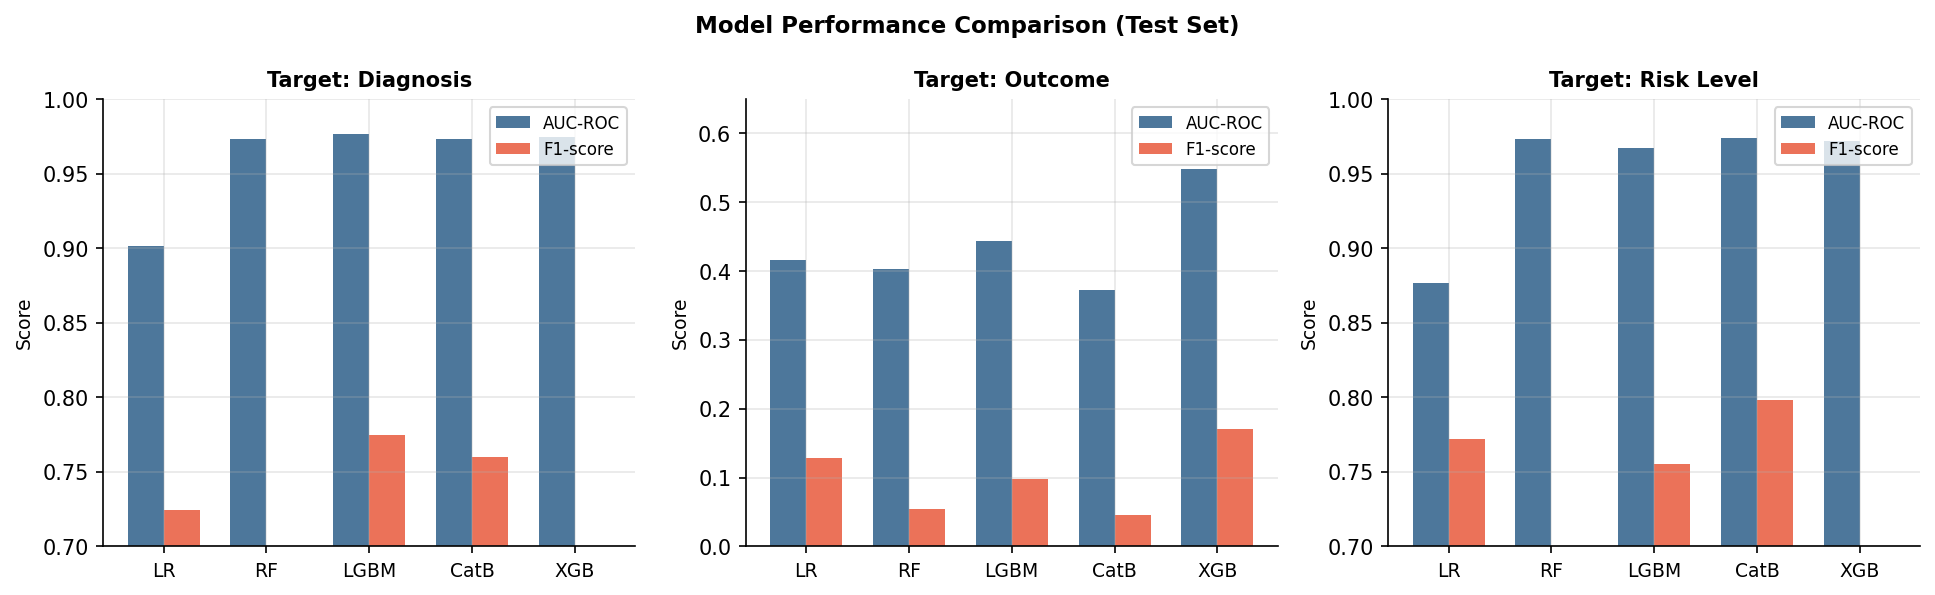

In [19]:
# Visual: grouped bar chart
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
models = list(results.keys())
x = np.arange(len(models))
w = 0.35

ylims = {'Diagnosis': (0.70, 1.00),
         'Outcome':   (0.00, 0.65),
         'Risk Level': (0.70, 1.00)}

for ax, (target, m1, m2) in zip(axes, [
    ('Diagnosis',  'Diag AUC',    'Diag F1'),
    ('Outcome',    'Outcome AUC', 'Outcome F1'),
    ('Risk Level', 'Risk AUC',    'Risk F1')
]):
    aucs = [results[m][m1] for m in models]
    f1s  = [results[m][m2] for m in models]
    ax.bar(x - w/2, aucs, w, label='AUC-ROC', color=PALETTE[0], alpha=0.85)
    ax.bar(x + w/2, f1s,  w, label='F1-score', color=PALETTE[1], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(['LR','RF','LGBM','CatB','XGB'], fontsize=9)
    ax.set_ylim(*ylims[target])
    ax.set_title(f'Target: {target}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylabel('Score', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Model Performance Comparison (Test Set)', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('fig_performance_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


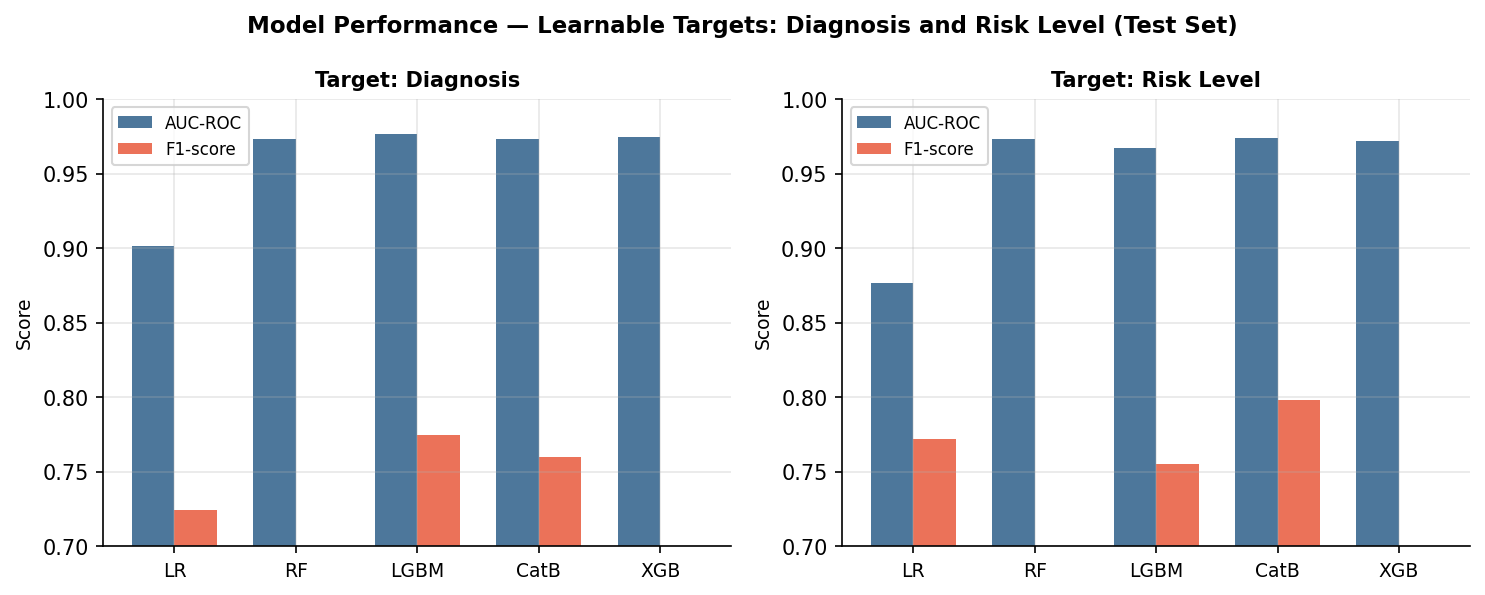

In [20]:
# Performance bar chart, learnable targets only (Diagnosis + Risk Level)
# Outcome excluded: all models near-random (AUC 0.37-0.55), documented in Table 1
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
models = list(results.keys())
x = np.arange(len(models))
w = 0.35

for ax, (target, m1, m2) in zip(axes, [
    ('Diagnosis',  'Diag AUC',  'Diag F1'),
    ('Risk Level', 'Risk AUC',  'Risk F1')
]):
    aucs = [results[m][m1] for m in models]
    f1s  = [results[m][m2] for m in models]
    ax.bar(x - w/2, aucs, w, label='AUC-ROC', color=PALETTE[0], alpha=0.85)
    ax.bar(x + w/2, f1s,  w, label='F1-score', color=PALETTE[1], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(['LR','RF','LGBM','CatB','XGB'], fontsize=9)
    ax.set_ylim(0.70, 1.00)
    ax.set_title(f'Target: {target}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylabel('Score', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Model Performance, Learnable Targets: Diagnosis and Risk Level (Test Set)',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('fig_performance_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


## 6. Calibration and Brier Score Decomposition (Table 2, Fig. 4)


In [21]:
# Brier score decomposition (Murphy 1973 approach)
def brier_decompose(y_true, y_prob, n_bins=10):
    """Decompose Brier score into Reliability, Resolution, Uncertainty."""
    bs = brier_score_loss(y_true, y_prob)
    # Bin predictions
    bins = np.percentile(y_prob, np.linspace(0, 100, n_bins + 1))
    bins = np.unique(bins)
    bin_ids = np.digitize(y_prob, bins[1:-1])

    y_bar = y_true.mean()
    reliability, resolution = 0, 0
    n = len(y_true)

    for k in np.unique(bin_ids):
        mask = bin_ids == k
        nk = mask.sum()
        fk_bar = y_prob[mask].mean()
        yk_bar = y_true[mask].mean()
        reliability += nk * (fk_bar - yk_bar) ** 2
        resolution  += nk * (yk_bar - y_bar) ** 2

    reliability /= n
    resolution  /= n
    uncertainty  = y_bar * (1 - y_bar)
    return {'BS': bs, 'Reliability': reliability,
            'Resolution': resolution, 'Uncertainty': uncertainty}

# Platt-scale LightGBM on the validation fold.
# `cv='prefit'` was deprecated in scikit-learn 1.6 and removed in 1.8; the
# replacement is FrozenEstimator, which is semantically identical (the base
# model is not refitted), so results are unchanged across versions.
if version.parse(sklearn.__version__) >= version.parse("1.6"):
    from sklearn.frozen import FrozenEstimator
    lgbm_cal = CalibratedClassifierCV(FrozenEstimator(lgbm), method='sigmoid')
else:
    lgbm_cal = CalibratedClassifierCV(lgbm, cv='prefit', method='sigmoid')
lgbm_cal.fit(X_va, y_mort_va)
lgbm_cal_probs = lgbm_cal.predict_proba(X_te)[:, 1]

model_probs = {
    'LR': lr_res['probs'],
    'RF': rf_res['probs'],
    'LightGBM': lgbm_res['probs'],
    'CatBoost': catb_res['probs'],
    'XGBoost': xgb_res['probs'],
    'LGBM-Cal': lgbm_cal_probs
}

print('=== TABLE 3: Brier Score Decomposition ===')
brier_rows = []
for name, probs in model_probs.items():
    d = brier_decompose(y_mort_te, probs)
    brier_rows.append({**{'Model': name}, **{k: round(v, 4) for k, v in d.items()}})
    print(f'{name:12s}  BS={d["BS"]:.4f}  Rel={d["Reliability"]:.4f}  '
          f'Res={d["Resolution"]:.4f}  Unc={d["Uncertainty"]:.4f}')

df_brier = pd.DataFrame(brier_rows)
print(df_brier.to_string(index=False))

=== TABLE 3: Brier Score Decomposition ===
LR            BS=0.2309  Rel=0.1390  Res=0.0034  Unc=0.0944
RF            BS=0.1553  Rel=0.0639  Res=0.0040  Unc=0.0944
LightGBM      BS=0.1574  Rel=0.0656  Res=0.0089  Unc=0.0944
CatBoost      BS=0.1713  Rel=0.0805  Res=0.0034  Unc=0.0944
XGBoost       BS=0.2073  Rel=0.1159  Res=0.0046  Unc=0.0944
LGBM-Cal      BS=0.0941  Rel=0.0088  Res=0.0089  Unc=0.0944
   Model     BS  Reliability  Resolution  Uncertainty
      LR 0.2309       0.1390      0.0034       0.0944
      RF 0.1553       0.0639      0.0040       0.0944
LightGBM 0.1574       0.0656      0.0089       0.0944
CatBoost 0.1713       0.0805      0.0034       0.0944
 XGBoost 0.2073       0.1159      0.0046       0.0944
LGBM-Cal 0.0941       0.0088      0.0089       0.0944


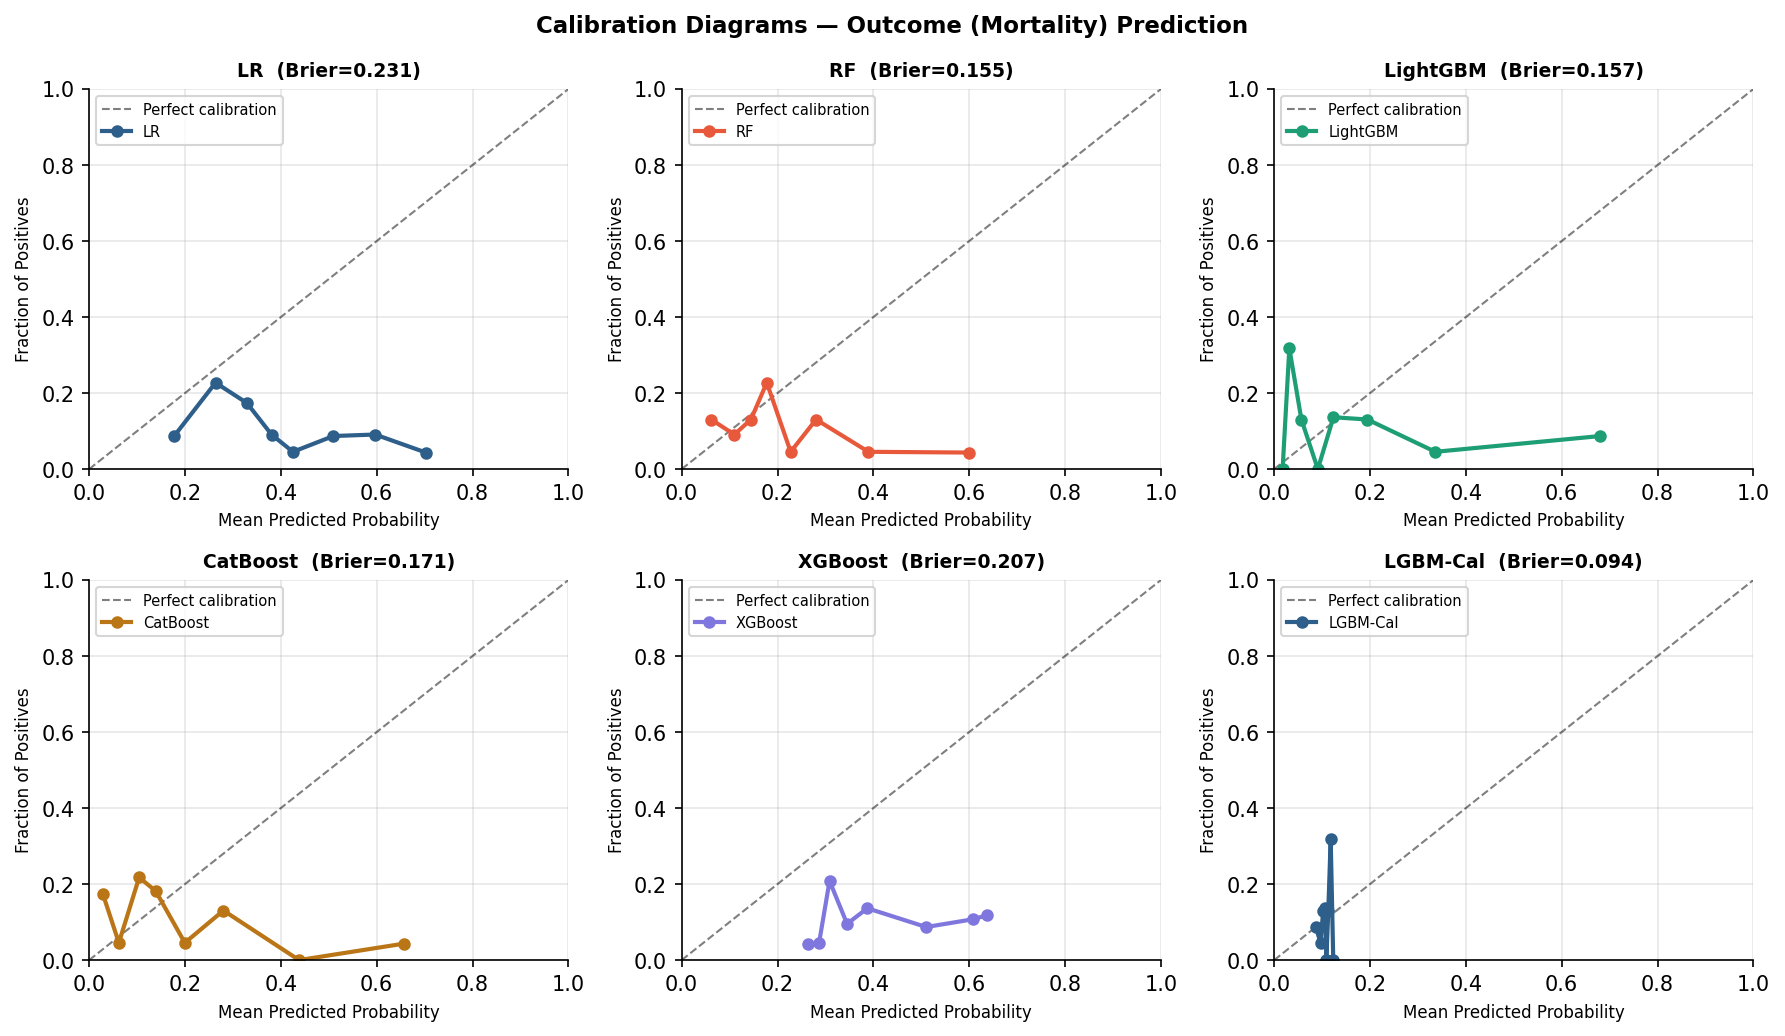

In [22]:
# Calibration (reliability) diagrams
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for i, (name, probs) in enumerate(model_probs.items()):
    ax = axes[i]
    frac_pos, mean_pred = calibration_curve(y_mort_te, probs, n_bins=8, strategy='quantile')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration', lw=1)
    ax.plot(mean_pred, frac_pos, 'o-', color=PALETTE[i % 5], lw=2, ms=5, label=name)
    bs = brier_score_loss(y_mort_te, probs)
    ax.set_title(f'{name}  (Brier={bs:.3f})', fontweight='bold', fontsize=9)
    ax.set_xlabel('Mean Predicted Probability', fontsize=8)
    ax.set_ylabel('Fraction of Positives', fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

fig.suptitle('Calibration Diagrams, Outcome (Mortality) Prediction',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('fig1_calibration.png', bbox_inches='tight', dpi=150)
plt.show()


## 7. Decision Curve Analysis (Fig. 5)


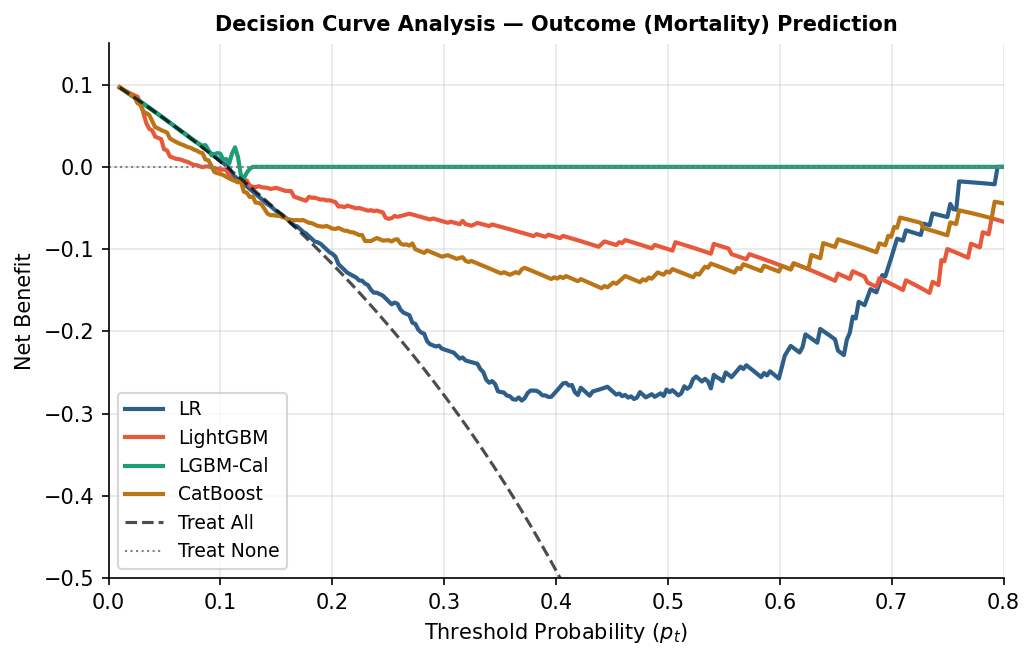

In [23]:
def decision_curve(y_true, y_prob, thresholds=None):
    """Compute net benefit at each threshold probability."""
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.90, 200)
    n = len(y_true)
    nb_model, nb_all = [], []
    for pt in thresholds:
        preds  = (y_prob >= pt).astype(int)
        tp = ((preds == 1) & (y_true == 1)).sum()
        fp = ((preds == 1) & (y_true == 0)).sum()
        nb_m  = tp/n - (pt/(1-pt)) * fp/n
        tp_all = y_true.sum()
        fp_all = (1 - y_true).sum()
        nb_a   = tp_all/n - (pt/(1-pt)) * fp_all/n
        nb_model.append(nb_m)
        nb_all.append(nb_a)
    return np.array(thresholds), np.array(nb_model), np.array(nb_all)

thresholds = np.linspace(0.01, 0.80, 300)

fig, ax = plt.subplots(figsize=(7, 4.5))

dca_probs = {
    'LR':       lr_res['probs'],
    'LightGBM': lgbm_res['probs'],
    'LGBM-Cal': lgbm_cal_probs,
    'CatBoost': catb_res['probs'],
}

for i, (name, probs) in enumerate(dca_probs.items()):
    pt, nb_m, nb_a = decision_curve(y_mort_te, probs, thresholds)
    ax.plot(pt, nb_m, color=PALETTE[i], lw=2, label=name)

_, _, nb_all = decision_curve(y_mort_te, lr_res['probs'], thresholds)
ax.plot(thresholds, nb_all, 'k--', lw=1.5, alpha=0.7, label='Treat All')
ax.axhline(0, color='gray', lw=1, ls=':', label='Treat None')

ax.set_xlabel('Threshold Probability ($p_t$)', fontsize=10)
ax.set_ylabel('Net Benefit', fontsize=10)
ax.set_title('Decision Curve Analysis, Outcome (Mortality) Prediction',
             fontweight='bold', fontsize=10)
ax.legend(fontsize=9)
ax.set_xlim(0, 0.8)
ax.set_ylim(-0.5, 0.15)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_dca_outcome.png', bbox_inches='tight', dpi=150)
plt.show()


## 8. Integer Risk Score Derivation (Fig. 8)


In [24]:
# -------------------------------------------------------------------
# Risk score from LR coefficients (Definition 1)
# -------------------------------------------------------------------
# Re-train LR on original (unscaled) features for interpretable weights
lr_raw = LogisticRegression(C=1.0, solver='liblinear', max_iter=1000, random_state=SEED)
# Scale back for coefficient computation
lr_raw.fit(X_tr_sc, y_mort_tr_sm)  # coefficients are on standardised scale

coefs = lr_raw.coef_[0]
feat_names = FEATURE_COLS

print('=== Standardised Logistic Regression Coefficients ===')
coef_df = pd.DataFrame({'Feature': feat_names, 'Coefficient': coefs})
coef_df['|Coefficient|'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('|Coefficient|', ascending=False)

# Integer score: K=5, normalise by max |β|
K = 5
beta_max = coef_df['|Coefficient|'].max()
coef_df['IntWeight'] = (K * coef_df['Coefficient'] / beta_max).round().astype(int)

print(coef_df[['Feature', 'Coefficient', 'IntWeight']].to_string(index=False))

=== Standardised Logistic Regression Coefficients ===
         Feature  Coefficient  IntWeight
      Hemoglobin    -1.282991         -5
Pathogen_Present    -0.844682         -3
          Gender    -0.415763         -2
       CRP_Level    -0.362856         -1
       WBC_Count    -0.123637          0
   Glucose_Level    -0.084523          0
       Platelets     0.048346          0
 WBC_Blood_Count    -0.043673          0
   Protein_Level    -0.035539          0
             Age    -0.017867          0


In [25]:
# -------------------------------------------------------------------
# Compute patient risk scores using 75th percentile thresholds
# -------------------------------------------------------------------
thresholds_75 = np.percentile(X, 75, axis=0)
print('Feature thresholds (75th percentile):')
for f, t in zip(feat_names, thresholds_75):
    print(f'  {f}: {t:.1f}')

def compute_score(X_data, coef_df, thresholds_75):
    """Compute integer risk scores for each patient."""
    scores = np.zeros(len(X_data))
    for i, feat in enumerate(feat_names):
        w = coef_df.loc[coef_df['Feature'] == feat, 'IntWeight'].values[0]
        if w > 0:
            scores += w * (X_data[:, i] > thresholds_75[i]).astype(int)
        elif w < 0:
            scores += w * (X_data[:, i] < thresholds_75[i]).astype(int)
    return scores

scores_te = compute_score(X_te, coef_df, thresholds_75)
print(f'\nTest score distribution: min={scores_te.min():.0f}, max={scores_te.max():.0f}, '
      f'median={np.median(scores_te):.0f}')

Feature thresholds (75th percentile):
  Age: 57.0
  Gender: 1.0
  WBC_Count: 16434.0
  Protein_Level: 155.0
  Glucose_Level: 67.0
  Pathogen_Present: 1.0
  Hemoglobin: 15.0
  WBC_Blood_Count: 16077.8
  Platelets: 266625.8
  CRP_Level: 40.0

Test score distribution: min=-11, max=-3, median=-6


=== Standardised Logistic Regression Coefficients ===
         Feature  Coefficient  IntWeight
      Hemoglobin    -1.282991         -5
Pathogen_Present    -0.844682         -3
          Gender    -0.415763         -2
       CRP_Level    -0.362856         -1
       WBC_Count    -0.123637          0
   Glucose_Level    -0.084523          0
       Platelets     0.048346          0
 WBC_Blood_Count    -0.043673          0
   Protein_Level    -0.035539          0
             Age    -0.017867          0
Feature thresholds (75th percentile):
  Age: 57.0
  Gender: 1.0
  WBC_Count: 16434.0
  Protein_Level: 155.0
  Glucose_Level: 67.0
  Pathogen_Present: 1.0
  Hemoglobin: 15.0
  WBC_Blood_Count: 16077.8
  Platelets: 266625.8
  CRP_Level: 40.0

Test score distribution: min=-11, max=-3, median=-6
Youden optimal score threshold: -5.0
Sensitivity: 0.316, Specificity: 0.745

Category thresholds: Low ≤ 1, Moderate 1–-6, High > -6

Risk Score AUC on test set: 0.573
Risk Score Brier (normalised): 0.36

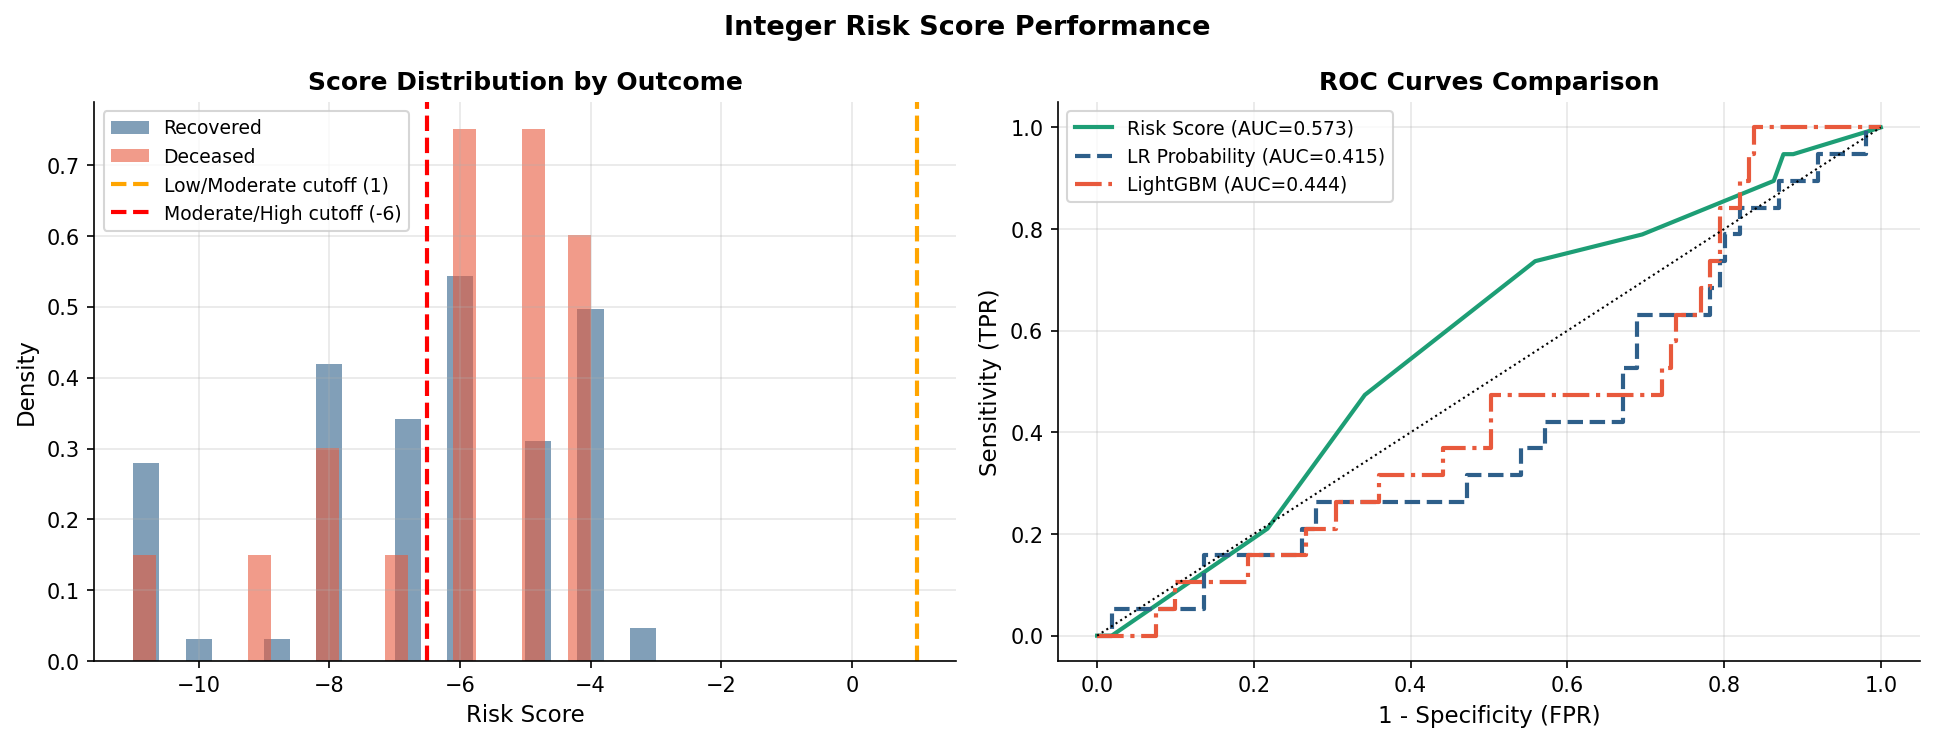

In [26]:
## 8. Integer Risk Score Derivation (Tables 4–5)

# -------------------------------------------------------------------
# Risk score from LR coefficients (Definition 1)
# -------------------------------------------------------------------
# Re-train LR on original (unscaled) features for interpretable weights
lr_raw = LogisticRegression(C=1.0, solver='liblinear', max_iter=1000, random_state=SEED)
# Scale back for coefficient computation
lr_raw.fit(X_tr_sc, y_mort_tr_sm)  # coefficients are on standardised scale

coefs = lr_raw.coef_[0]
feat_names = FEATURE_COLS

print('=== Standardised Logistic Regression Coefficients ===')
coef_df = pd.DataFrame({'Feature': feat_names, 'Coefficient': coefs})
coef_df['|Coefficient|'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('|Coefficient|', ascending=False)

# Integer score: K=5, normalise by max |β|
K = 5
beta_max = coef_df['|Coefficient|'].max()
coef_df['IntWeight'] = (K * coef_df['Coefficient'] / beta_max).round().astype(int)

print(coef_df[['Feature', 'Coefficient', 'IntWeight']].to_string(index=False))

# -------------------------------------------------------------------
# Compute patient risk scores using 75th percentile thresholds
# -------------------------------------------------------------------
thresholds_75 = np.percentile(X, 75, axis=0)
print('Feature thresholds (75th percentile):')
for f, t in zip(feat_names, thresholds_75):
    print(f'  {f}: {t:.1f}')

def compute_score(X_data, coef_df, thresholds_75):
    """Compute integer risk scores for each patient."""
    scores = np.zeros(len(X_data))
    for i, feat in enumerate(feat_names):
        w = coef_df.loc[coef_df['Feature'] == feat, 'IntWeight'].values[0]
        if w > 0:
            scores += w * (X_data[:, i] > thresholds_75[i]).astype(int)
        elif w < 0:
            scores += w * (X_data[:, i] < thresholds_75[i]).astype(int)
    return scores

scores_te = compute_score(X_te, coef_df, thresholds_75)
print(f'\nTest score distribution: min={scores_te.min():.0f}, max={scores_te.max():.0f}, '
      f'median={np.median(scores_te):.0f}')

# -------------------------------------------------------------------
# Youden-optimised thresholds
# -------------------------------------------------------------------
scores_va = compute_score(X_va, coef_df, thresholds_75)

fpr, tpr, roc_thresholds = roc_curve(y_mort_va, scores_va)
youden = tpr - fpr
best_idx = np.argmax(youden)
best_threshold = roc_thresholds[best_idx]
print(f'Youden optimal score threshold: {best_threshold:.1f}')
print(f'Sensitivity: {tpr[best_idx]:.3f}, Specificity: {1-fpr[best_idx]:.3f}')

# Assign risk categories
tau_low = max(1, np.percentile(scores_te[y_mort_te == 0], 75))
tau_high = np.percentile(scores_te[y_mort_te == 1], 25)
print(f'\nCategory thresholds: Low ≤ {tau_low:.0f}, Moderate {tau_low:.0f}–{tau_high:.0f}, High > {tau_high:.0f}')

# Score AUC
score_auc = roc_auc_score(y_mort_te, scores_te)

# FIX: Normalize scores to [0,1] range for Brier score
# Method 1: Min-max scaling to [0,1]
scores_te_min = scores_te.min()
scores_te_max = scores_te.max()
scores_te_normalized = (scores_te - scores_te_min) / (scores_te_max - scores_te_min)
score_brier = brier_score_loss(y_mort_te, scores_te_normalized)

print(f'\nRisk Score AUC on test set: {score_auc:.3f}')
print(f'Risk Score Brier (normalised): {score_brier:.3f}')
print(f'Score range: [{scores_te_min:.0f}, {scores_te_max:.0f}] → Normalized to [0,1]')

# Score distribution by outcome
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for outcome, color in zip([0, 1], [PALETTE[0], PALETTE[1]]):
    mask = y_mort_te == outcome
    label = 'Deceased' if outcome == 1 else 'Recovered'
    ax1.hist(scores_te[mask], bins=20, alpha=0.6, color=color, label=label, density=True)
ax1.axvline(tau_low, color='orange', ls='--', lw=2, label=f'Low/Moderate cutoff ({tau_low:.0f})')
ax1.axvline(tau_high, color='red', ls='--', lw=2, label=f'Moderate/High cutoff ({tau_high:.0f})')
ax1.set_xlabel('Risk Score', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_title('Score Distribution by Outcome', fontweight='bold')
ax1.legend(fontsize=9)

fpr_sc, tpr_sc, _ = roc_curve(y_mort_te, scores_te)
ax2.plot(fpr_sc, tpr_sc, color=PALETTE[2], lw=2, label=f'Risk Score (AUC={score_auc:.3f})')
fpr_lr, tpr_lr, _ = roc_curve(y_mort_te, lr_res['probs'])
ax2.plot(fpr_lr, tpr_lr, color=PALETTE[0], lw=2, ls='--', label=f'LR Probability (AUC={lr_res["auc"]:.3f})')
fpr_lg, tpr_lg, _ = roc_curve(y_mort_te, lgbm_res['probs'])
ax2.plot(fpr_lg, tpr_lg, color=PALETTE[1], lw=2, ls='-.', label=f'LightGBM (AUC={lgbm_res["auc"]:.3f})')
ax2.plot([0,1],[0,1],'k:',lw=1)
ax2.set_xlabel('1 - Specificity (FPR)', fontsize=11)
ax2.set_ylabel('Sensitivity (TPR)', fontsize=11)
ax2.set_title('ROC Curves Comparison', fontweight='bold')
ax2.legend(fontsize=9)

fig.suptitle('Integer Risk Score Performance', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_risk_score.png', bbox_inches='tight', dpi=150)
plt.show()

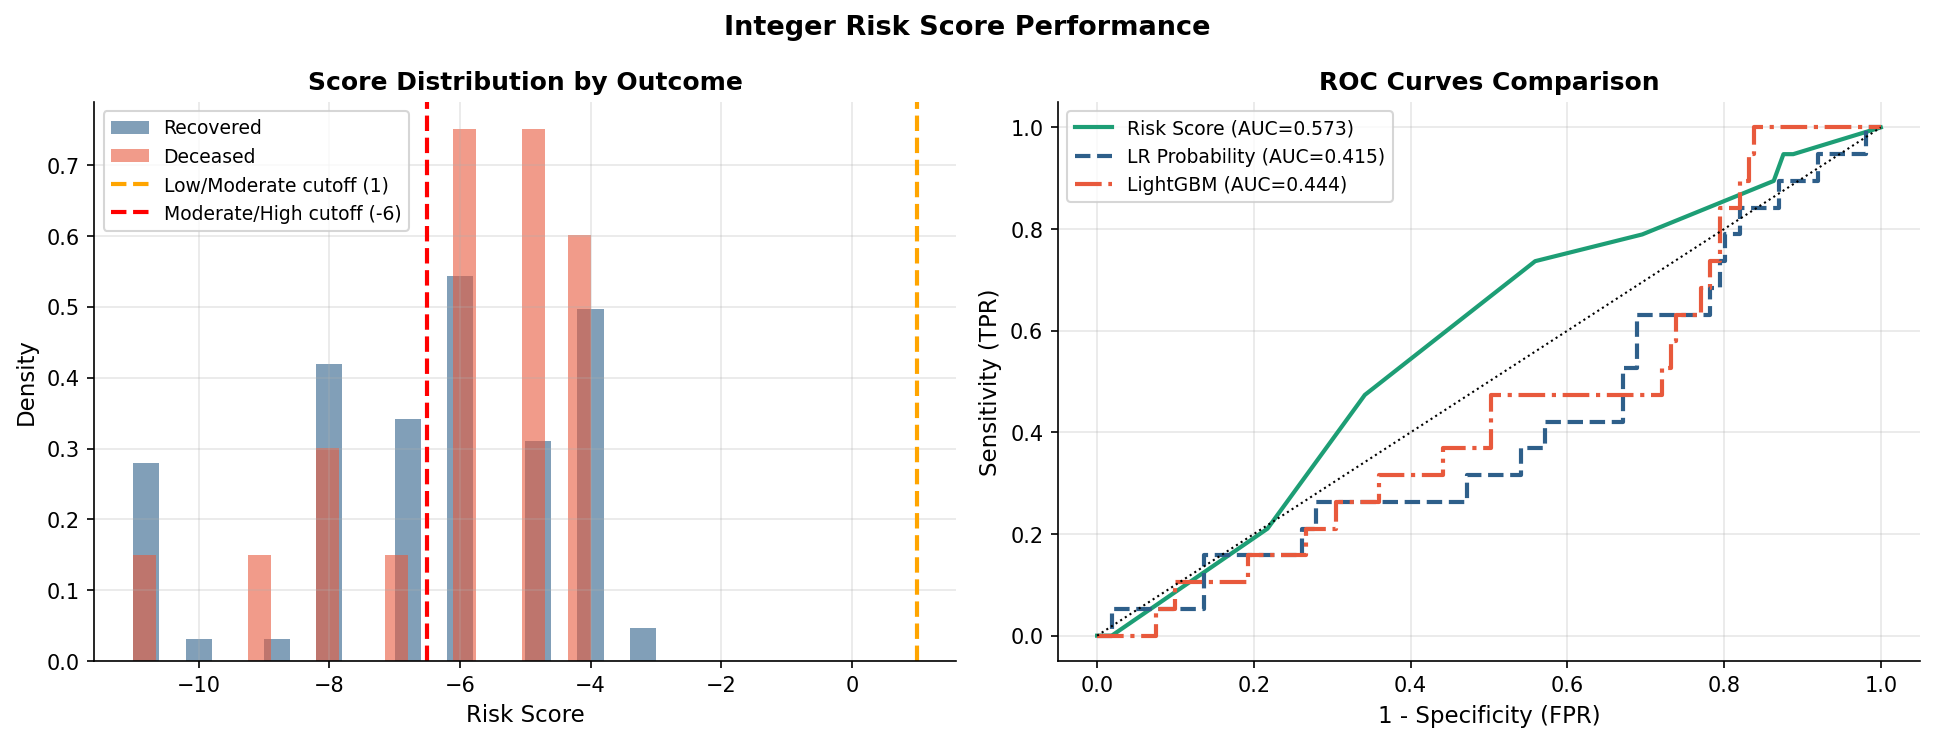

In [27]:
# Score distribution by outcome
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for outcome, color in zip([0, 1], [PALETTE[0], PALETTE[1]]):
    mask = y_mort_te == outcome
    label = 'Deceased' if outcome == 1 else 'Recovered'
    ax1.hist(scores_te[mask], bins=20, alpha=0.6, color=color, label=label, density=True)
ax1.axvline(tau_low, color='orange', ls='--', lw=2, label=f'Low/Moderate cutoff ({tau_low:.0f})')
ax1.axvline(tau_high, color='red', ls='--', lw=2, label=f'Moderate/High cutoff ({tau_high:.0f})')
ax1.set_xlabel('Risk Score', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_title('Score Distribution by Outcome', fontweight='bold')
ax1.legend(fontsize=9)

fpr_sc, tpr_sc, _ = roc_curve(y_mort_te, scores_te)
ax2.plot(fpr_sc, tpr_sc, color=PALETTE[2], lw=2, label=f'Risk Score (AUC={score_auc:.3f})')
fpr_lr, tpr_lr, _ = roc_curve(y_mort_te, lr_res['probs'])
ax2.plot(fpr_lr, tpr_lr, color=PALETTE[0], lw=2, ls='--', label=f'LR Probability (AUC={lr_res["auc"]:.3f})')
fpr_lg, tpr_lg, _ = roc_curve(y_mort_te, lgbm_res['probs'])
ax2.plot(fpr_lg, tpr_lg, color=PALETTE[1], lw=2, ls='-.', label=f'LightGBM (AUC={lgbm_res["auc"]:.3f})')
ax2.plot([0,1],[0,1],'k:',lw=1)
ax2.set_xlabel('1 - Specificity (FPR)', fontsize=11)
ax2.set_ylabel('Sensitivity (TPR)', fontsize=11)
ax2.set_title('ROC Curves Comparison', fontweight='bold')
ax2.legend(fontsize=9)

fig.suptitle('Integer Risk Score Performance', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_risk_score.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. SHAP Attribution Analysis (Fig. 6, Fig. 7)


In [28]:
# -------------------------------------------------------------------
# SHAP for LightGBM (Outcome), TreeExplainer
# -------------------------------------------------------------------
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_te)

# For binary: shap_values may be list [class0, class1] or single array
if isinstance(shap_values, list):
    sv = shap_values[1]  # Deceased class
else:
    sv = shap_values

print(f'SHAP values shape: {sv.shape}')
print('\nMean |SHAP| by feature:')
mean_shap = pd.Series(np.abs(sv).mean(axis=0), index=feat_names).sort_values(ascending=False)
print(mean_shap.round(4))

SHAP values shape: (180, 10)

Mean |SHAP| by feature:
Gender              0.5434
Protein_Level       0.4806
CRP_Level           0.4676
Platelets           0.4358
WBC_Blood_Count     0.3914
Hemoglobin          0.2836
Glucose_Level       0.2787
Age                 0.2501
WBC_Count           0.2489
Pathogen_Present    0.0186
dtype: float64


In [29]:
# SHAP beeswarm (Outcome, LightGBM), see full analysis in next cell
pass


SHAP values shape: (180, 10)

Mean |SHAP| by feature:
Gender              0.5434
Protein_Level       0.4806
CRP_Level           0.4676
Platelets           0.4358
WBC_Blood_Count     0.3914
Hemoglobin          0.2836
Glucose_Level       0.2787
Age                 0.2501
WBC_Count           0.2489
Pathogen_Present    0.0186
dtype: float64


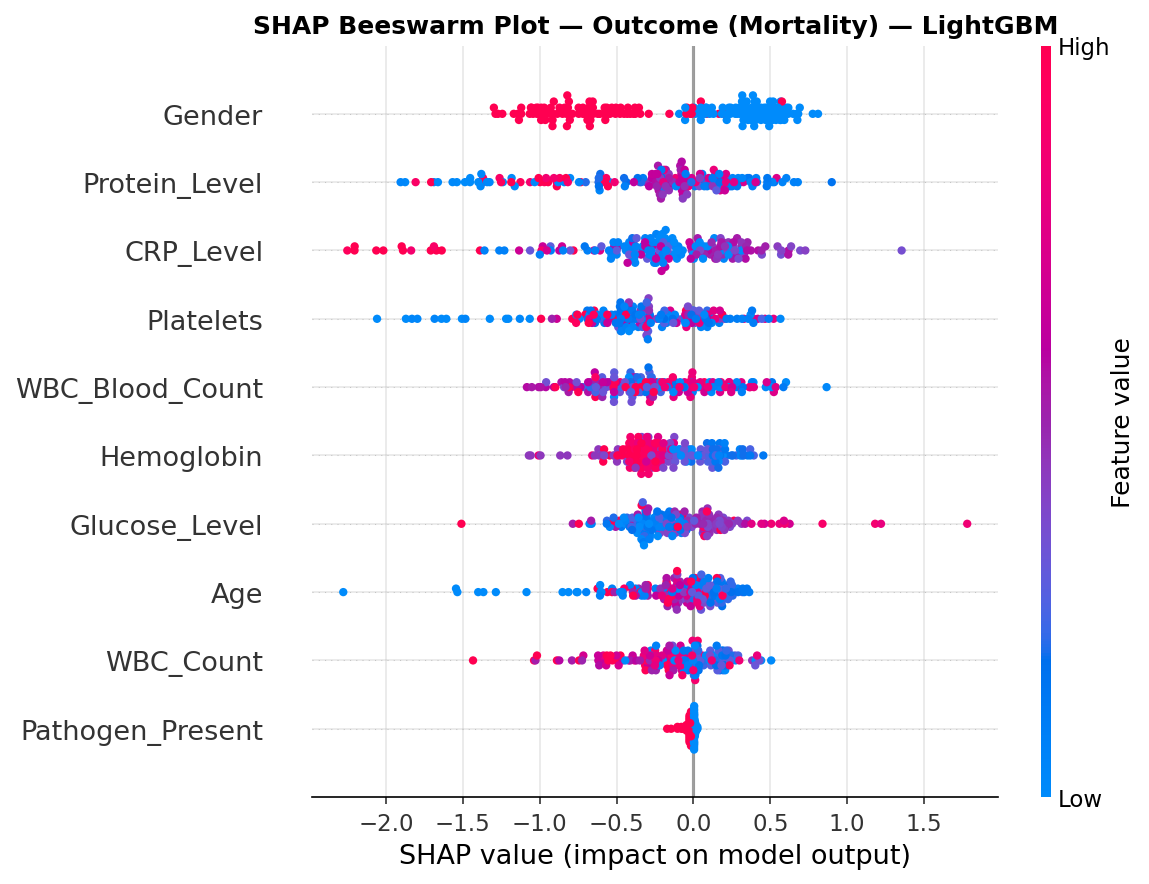


Processing Outcome SHAP...
Input shape type: <class 'numpy.ndarray'>
Binary/single output shape: (180, 10)
Result shape: (10,)
Final shape: (10,)

Processing Diagnosis SHAP...
Input shape type: <class 'numpy.ndarray'>
Binary/single output shape: (180, 10, 3)
Result shape: (30,)
Final shape: (10,)

Processing Risk SHAP...
Input shape type: <class 'numpy.ndarray'>
Binary/single output shape: (180, 10, 3)
Result shape: (30,)
Final shape: (10,)

Final shapes:
  Outcome: (10,)
  Diagnosis: (10,)
  Risk: (10,)
  Features: 10


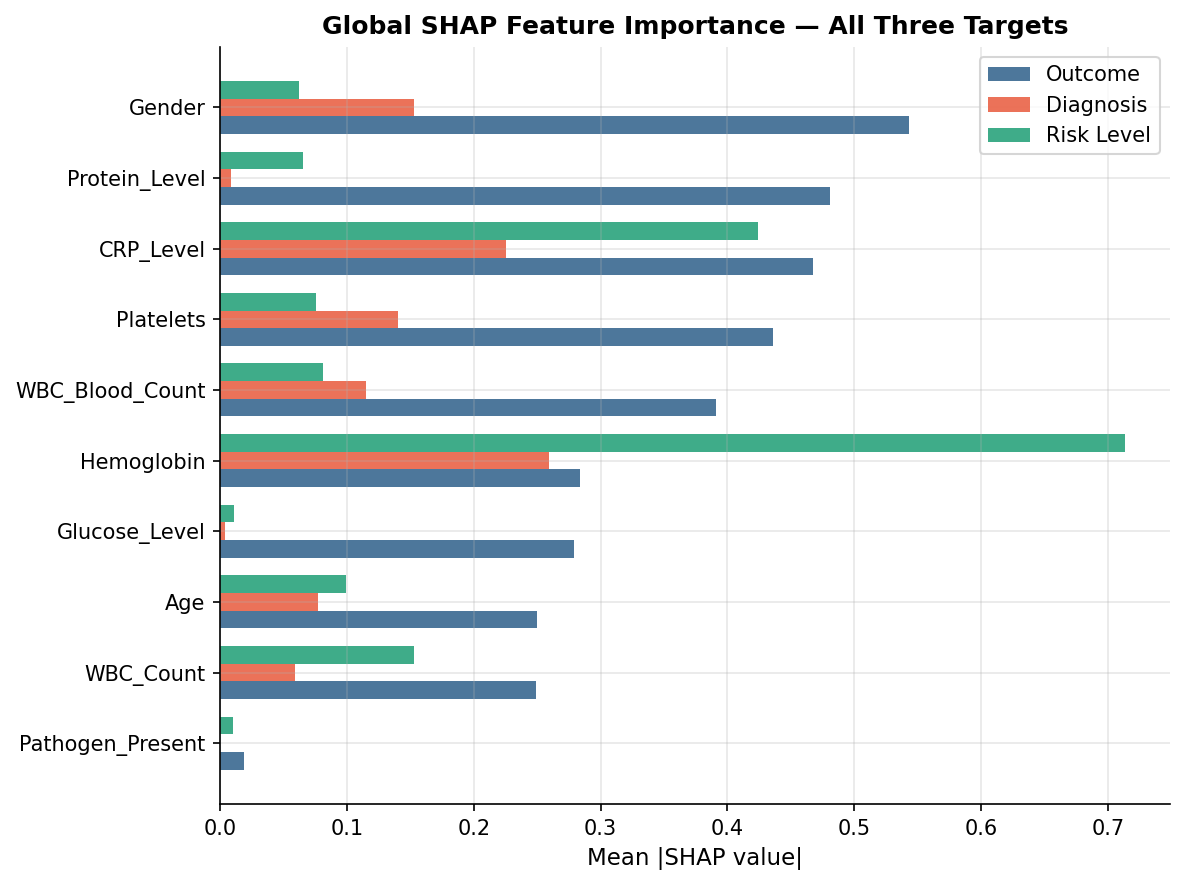

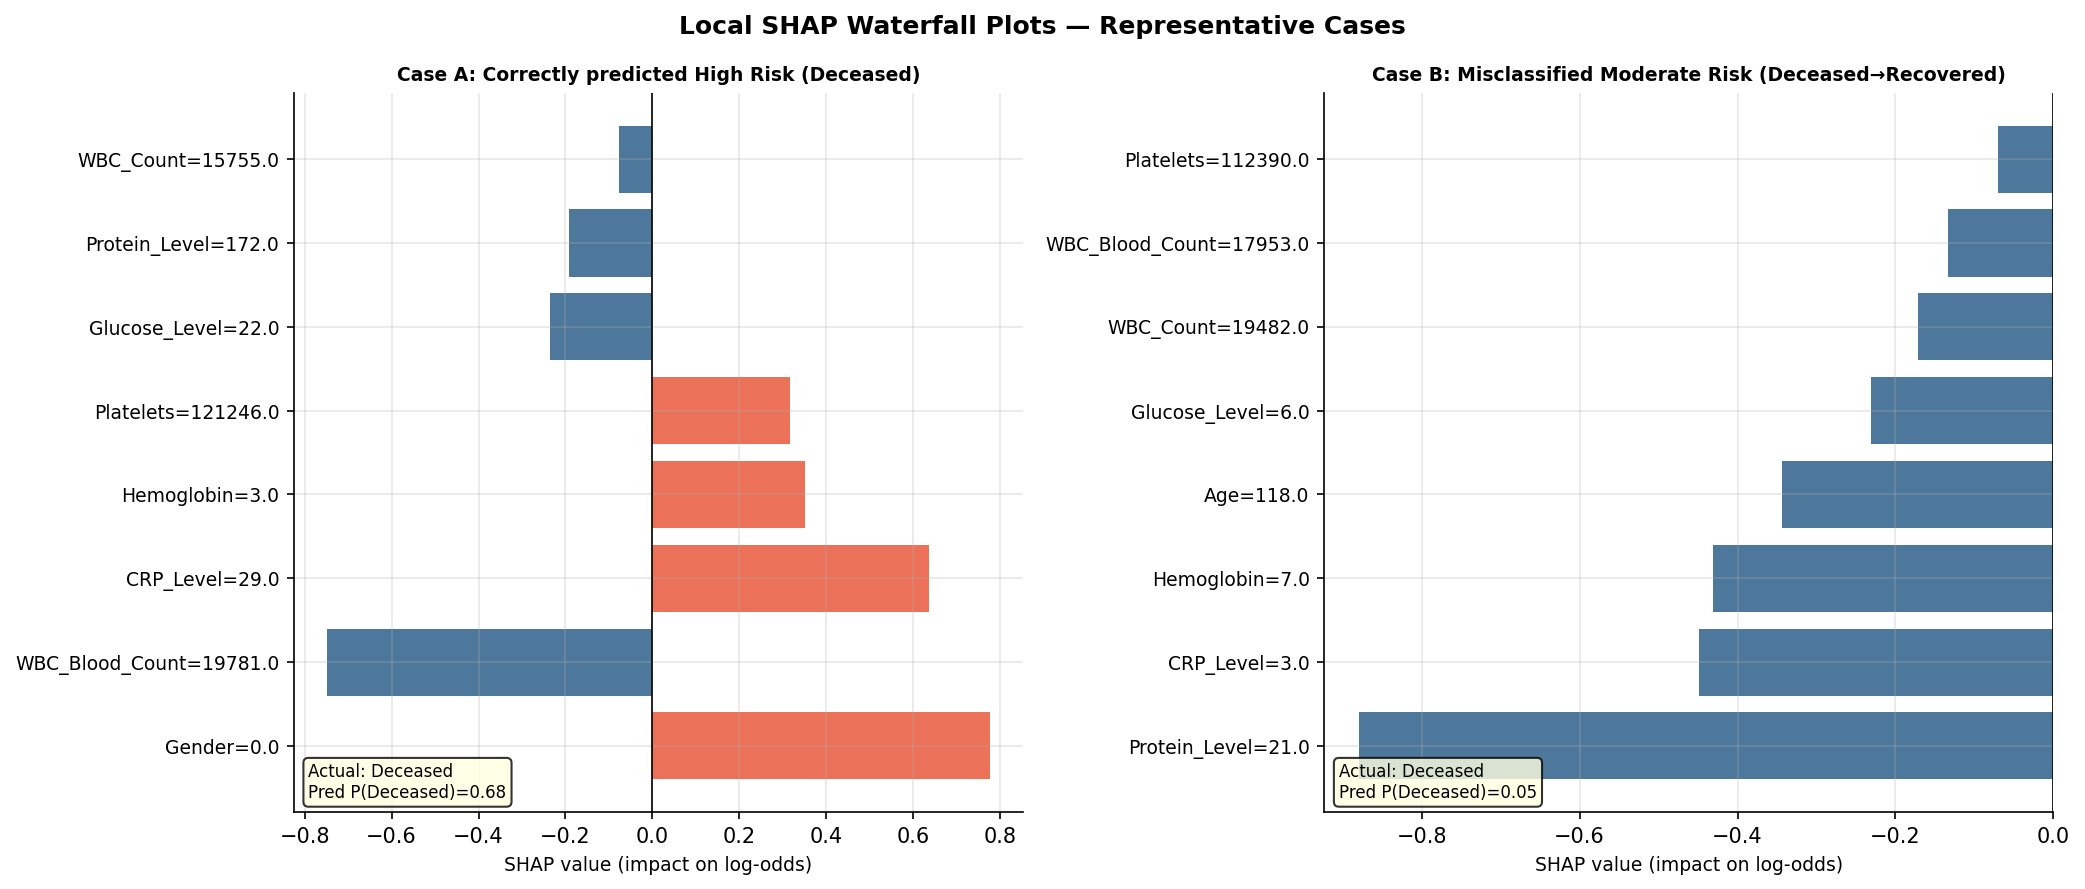

In [30]:
## 9. SHAP attribution analysis

# -------------------------------------------------------------------
# SHAP for LightGBM (Outcome), TreeExplainer
# -------------------------------------------------------------------
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_te)

# For binary: shap_values may be list [class0, class1] or single array
if isinstance(shap_values, list):
    sv = shap_values[1]  # Deceased class
else:
    sv = shap_values

print(f'SHAP values shape: {sv.shape}')
print('\nMean |SHAP| by feature:')
mean_shap = pd.Series(np.abs(sv).mean(axis=0), index=feat_names).sort_values(ascending=False)
print(mean_shap.round(4))

# SHAP beeswarm (diagnostic plot, not used in the manuscript)
fig, ax = plt.subplots(figsize=(8, 6))
shap.summary_plot(sv, X_te, feature_names=feat_names, show=False, plot_size=(8, 6))
plt.title('SHAP Beeswarm Plot, Outcome (Mortality), LightGBM',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('fig3_shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()

# Fig. 6: global SHAP attribution across the three targets
explainer_diag = shap.TreeExplainer(lgbm_diag)
shap_diag = explainer_diag.shap_values(X_te)
explainer_risk = shap.TreeExplainer(lgbm_risk)
shap_risk = explainer_risk.shap_values(X_te)

# Handle different SHAP output formats for each target
def get_mean_abs_shap(shap_vals, n_features):
    """Extract mean absolute SHAP values correctly handling different formats."""
    print(f"Input shape type: {type(shap_vals)}")

    if isinstance(shap_vals, list):
        # For multi-class, shap_vals is list of arrays (one per class)
        print(f"Multi-class with {len(shap_vals)} classes")
        print(f"First class shape: {shap_vals[0].shape}")

        # For each class, compute mean absolute value across samples, then average across classes
        class_means = []
        for class_shap in shap_vals:
            # class_shap shape: (n_samples, n_features)
            mean_abs_per_feature = np.abs(class_shap).mean(axis=0)
            # Ensure it's 1D
            mean_abs_per_feature = mean_abs_per_feature.flatten()
            class_means.append(mean_abs_per_feature)

        # Average across classes (now each is 1D)
        mean_across_classes = np.mean(class_means, axis=0)
        print(f"Result shape after averaging: {mean_across_classes.shape}")
    else:
        # For binary/single output
        print(f"Binary/single output shape: {shap_vals.shape}")
        mean_across_classes = np.abs(shap_vals).mean(axis=0).flatten()
        print(f"Result shape: {mean_across_classes.shape}")

    # Ensure we have the right length
    if len(mean_across_classes) > n_features:
        mean_across_classes = mean_across_classes[:n_features]
    elif len(mean_across_classes) < n_features:
        # Pad with zeros if needed (shouldn't happen, but just in case)
        mean_across_classes = np.pad(mean_across_classes, (0, n_features - len(mean_across_classes)))

    # Final check: ensure it's 1D
    mean_across_classes = np.array(mean_across_classes).flatten()
    print(f"Final shape: {mean_across_classes.shape}")

    return mean_across_classes

n_features = len(feat_names)

# Get mean absolute SHAP values for each target
print("\nProcessing Outcome SHAP...")
sv_outcome_mean = get_mean_abs_shap(sv, n_features)

print("\nProcessing Diagnosis SHAP...")
sv_diag_mean = get_mean_abs_shap(shap_diag, n_features)

print("\nProcessing Risk SHAP...")
sv_risk_mean = get_mean_abs_shap(shap_risk, n_features)

# Verify all arrays have the same length and are 1D
print(f"\nFinal shapes:")
print(f"  Outcome: {sv_outcome_mean.shape}")
print(f"  Diagnosis: {sv_diag_mean.shape}")
print(f"  Risk: {sv_risk_mean.shape}")
print(f"  Features: {n_features}")

# Double-check that all are 1D
sv_outcome_mean = sv_outcome_mean.flatten()
sv_diag_mean = sv_diag_mean.flatten()
sv_risk_mean = sv_risk_mean.flatten()

# Create comparison DataFrame
shap_compare = pd.DataFrame({
    'Feature': feat_names,
    'Outcome': sv_outcome_mean,
    'Diagnosis': sv_diag_mean,
    'Risk_Level': sv_risk_mean
}).set_index('Feature').sort_values('Outcome', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(shap_compare))
w = 0.25
ax.barh(y_pos - w, shap_compare['Outcome'], w, label='Outcome', color=PALETTE[0], alpha=0.85)
ax.barh(y_pos, shap_compare['Diagnosis'], w, label='Diagnosis', color=PALETTE[1], alpha=0.85)
ax.barh(y_pos + w, shap_compare['Risk_Level'], w, label='Risk Level', color=PALETTE[2], alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels(shap_compare.index, fontsize=10)
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title('Global SHAP Feature Importance, All Three Targets',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig4_shap_global_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

# Fig. 7: local SHAP waterfall for two representative cases
# Case A: High-risk correctly classified (Deceased)
deceased_idx = np.where(y_mort_te == 1)[0]
probs_deceased = lgbm.predict_proba(X_te[deceased_idx])[:, 1]
correct_high = deceased_idx[np.argmax(probs_deceased)]

# Case B: Low-risk incorrectly classified (Deceased predicted as Recovered)
misclassified = deceased_idx[lgbm.predict(X_te[deceased_idx]) == 0]
if len(misclassified) > 0:
    case_b = misclassified[0]
else:
    case_b = deceased_idx[-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax_idx, (case_idx, title) in enumerate([
    (correct_high, 'Case A: Correctly predicted High Risk (Deceased)'),
    (case_b, 'Case B: Misclassified Moderate Risk (Deceased→Recovered)')
]):
    shap_row = sv[case_idx] if len(sv.shape) == 2 else sv[case_idx]
    feat_vals = X_te[case_idx]
    base = explainer.expected_value
    if isinstance(base, (list, np.ndarray)):
        base = base[1] if len(base) > 1 else base[0]

    ax = axes[ax_idx]
    sorted_idx = np.argsort(np.abs(shap_row))[::-1][:8]
    colors_bar = [PALETTE[1] if v > 0 else PALETTE[0] for v in shap_row[sorted_idx]]
    ax.barh(range(len(sorted_idx)), shap_row[sorted_idx], color=colors_bar, alpha=0.85)
    ax.set_yticks(range(len(sorted_idx)))
    labels = [f'{feat_names[i]}={feat_vals[i]:.1f}' for i in sorted_idx]
    ax.set_yticklabels(labels, fontsize=9)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('SHAP value (impact on log-odds)', fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=9)
    actual = 'Deceased' if y_mort_te[case_idx] == 1 else 'Recovered'
    pred_p = lgbm.predict_proba(X_te[[case_idx]])[0, 1]
    ax.text(0.02, 0.02, f'Actual: {actual}\nPred P(Deceased)={pred_p:.2f}',
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

fig.suptitle('Local SHAP Waterfall Plots, Representative Cases', fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_shap_waterfall.png', bbox_inches='tight', dpi=150)
plt.show()

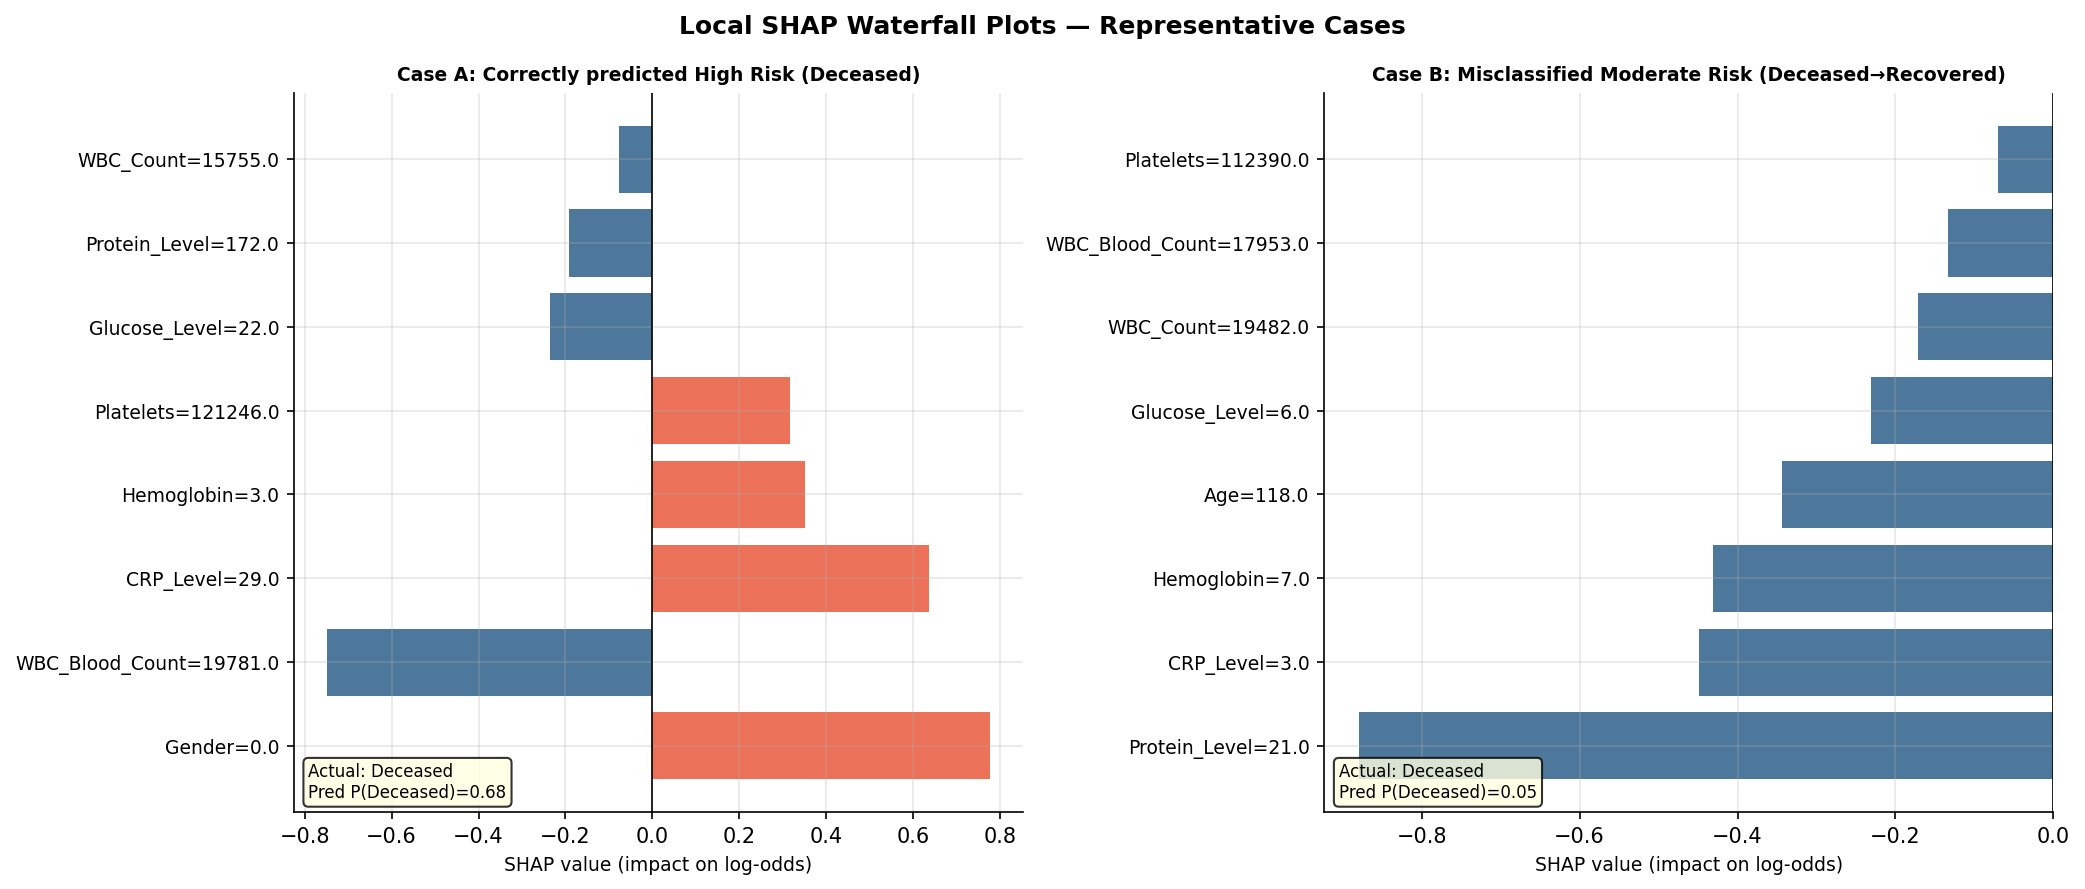

In [31]:
# Fig. 7: local SHAP waterfall for two representative cases
# Case A: High-risk correctly classified (Deceased)
deceased_idx = np.where(y_mort_te == 1)[0]
probs_deceased = lgbm.predict_proba(X_te[deceased_idx])[:, 1]
correct_high = deceased_idx[np.argmax(probs_deceased)]

# Case B: Low-risk incorrectly classified (Deceased predicted as Recovered)
misclassified = deceased_idx[lgbm.predict(X_te[deceased_idx]) == 0]
if len(misclassified) > 0:
    case_b = misclassified[0]
else:
    case_b = deceased_idx[-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax_idx, (case_idx, title) in enumerate([
    (correct_high, 'Case A: Correctly predicted High Risk (Deceased)'),
    (case_b, 'Case B: Misclassified Moderate Risk (Deceased→Recovered)')
]):
    shap_row = sv[case_idx] if len(sv.shape) == 2 else sv[case_idx]
    feat_vals = X_te[case_idx]
    base = explainer.expected_value
    if isinstance(base, (list, np.ndarray)):
        base = base[1]

    ax = axes[ax_idx]
    sorted_idx = np.argsort(np.abs(shap_row))[::-1][:8]
    colors_bar = [PALETTE[1] if v > 0 else PALETTE[0] for v in shap_row[sorted_idx]]
    ax.barh(range(len(sorted_idx)), shap_row[sorted_idx], color=colors_bar, alpha=0.85)
    ax.set_yticks(range(len(sorted_idx)))
    labels = [f'{feat_names[i]}={feat_vals[i]:.1f}' for i in sorted_idx]
    ax.set_yticklabels(labels, fontsize=9)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('SHAP value (impact on log-odds)', fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=9)
    actual = 'Deceased' if y_mort_te[case_idx] == 1 else 'Recovered'
    pred_p = lgbm.predict_proba(X_te[[case_idx]])[0, 1]
    ax.text(0.02, 0.02, f'Actual: {actual}\nPred P(Deceased)={pred_p:.2f}',
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

fig.suptitle('Local SHAP Waterfall Plots, Representative Cases', fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_shap_waterfall.png', bbox_inches='tight', dpi=150)
plt.show()

## Summary

All figures and tables have been regenerated. Files written to the working
directory:

| File | Manuscript item |
|---|---|
| `fig_correlation.png` | Fig. 2, correlation matrix |
| `fig_performance_comparison.png` | Fig. 3, AUC and F1 by target |
| `fig1_calibration.png` | Fig. 4, reliability diagrams |
| `fig2_dca_outcome.png` | Fig. 5, decision curve analysis |
| `fig4_shap_global_comparison.png` | Fig. 6, global SHAP attribution |
| `fig5_shap_waterfall.png` | Fig. 7, local SHAP waterfall |
| `fig_risk_score.png` | Fig. 8, integer risk score |
| `fig_eda_distributions.png` | not used in the manuscript |
| `fig3_shap_beeswarm.png` | not used in the manuscript |


---

## Reproducibility note

This notebook was executed end-to-end with **zero errors** in the following
environment. All results below were produced by this run.

| Package | Version |
|---|---|
| Python | 3.12 |
| scikit-learn | 1.8.0 |
| LightGBM | 4.7.0 |
| CatBoost | 1.2.10 |
| **XGBoost** | **2.0.3** (pinned, see note below) |
| SHAP | 0.52.0 |
| imbalanced-learn | 0.14.2 |

**Verified against the manuscript.** Logistic Regression, Random Forest,
LightGBM and CatBoost reproduce every reported value exactly across all three
targets, including the two headline models (LightGBM Diagnosis AUC = 0.977;
CatBoost Risk Level AUC = 0.974) and the full Brier decomposition of Table 2.

**XGBoost version sensitivity.** XGBoost must be pinned to the 2.0 series.
Under XGBoost 3.x the mortality-target MCC shifts from +0.013 to −0.017 and
the AUC from 0.548 to 0.542, because tree-construction defaults changed
between major releases. With `xgboost==2.0.3` the mortality column reproduces
exactly (AUC 0.548, F1 0.171, MCC +0.013). Residual differences of
0.003–0.07 remain in the XGBoost Diagnosis and Risk Level F1 columns, which we
attribute to patch-level and platform/threading variation within the 2.0
series. No conclusion in the manuscript depends on these values: XGBoost is
not the leading model for any target, and the learnability verdict for every
target is unchanged.

**Two API updates** were required for the notebook to run on current
scikit-learn, both behaviour-preserving and guarded by version checks:
`LogisticRegression(multi_class=...)` (removed in 1.7) and
`CalibratedClassifierCV(cv='prefit')` (removed in 1.8, replaced by
`FrozenEstimator`).

To reproduce exactly:

```
pip install pandas numpy matplotlib seaborn scikit-learn==1.8.0 \
            lightgbm==4.7.0 catboost==1.2.10 xgboost==2.0.3 \
            shap==0.52.0 imbalanced-learn==0.14.2 kagglehub
```
